In [1]:
try:
    kjghfdhdsfh3
    assert False
except NameError:
    kjghfdhdsfh3 = 3
    pass
import os

In [2]:
list(range(6,24))

[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

In [3]:
kjghfdhdsfh3 = 3
import os, importlib
import sys, pathlib
import psutil
import threadpoolctl
# Get the current process
import numba
# numba.config.THREADING_LAYER = 'forksafe'

sys.path += ["../diff_co_mpc/"]
workstation = True
# sys.path += [str(pathlib.Path(os.getcwd()) / '..' / "diff_co_mpc")]
if workstation:
    # LD_PRELOAD=<path>/libgomp.so
    # os.environ['LD_PRELOAD'] = '/usr/lib/x86_64-linux-gnu/libmkl_core.so:/usr/lib/x86_64-linux-gnu/libmkl_intel_thread.so:/usr/lib/x86_64-linux-gnu/libmkl_intel_lp64.so:/usr/lib/x86_64-linux-gnu/libiomp5.so:'
    os.environ["OMP_NUM_THREADS"] = "12"  #
    os.environ["MKL_NUM_THREADS"] = "12"  #    
    # os.environ['TORCH_LOGS'] = '+dynamic'
    os.environ["OMP_PLACES"] = "{12:23}"
    os.environ["OMP_PROC_BIND"] = "true"
    os.environ['MKL_THREADING_LAYER'] = 'GNU'
    p = psutil.Process()
    p.cpu_affinity(list(range(12,24)))
else:
    p = psutil.Process()
    # LD_PRELOAD=<path>/libgomp.so
    os.environ["OMP_NUM_THREADS"] = "3"  #
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
    os.environ["TORCHINDUCTOR_COMPILE_THREAD"] = "1"
    # TORCH_LOGS=dynamic
    os.environ['TORCH_LOGS'] = '+dynamic'
    os.environ["OMP_PLACES"] = "{0,2,4}"
    os.environ["OMP_PROC_BIND"] = "true"
    p.cpu_affinity([0,1,2,3,4,5])
import casadi as ca
from IPython.display import clear_output, display, SVG
from functools import partial
from toolz import (
    memoize,
    pipe,
    accumulate,
    groupby,
    compose,
    compose_left,
    merge,
    first,
)
from toolz.curried import do
from collections import namedtuple
import typing as T
import numpy as np
import torch
import itertools
import pathlib, os
from matplotlib import pyplot as plt
import time
import copy
import threadpoolctl

import importlib
from pydrake.all import (
    ModelInstanceIndex,
    RigidTransform,
    RotationMatrix,
    RollPitchYaw,
    StartMeshcat,
)
import threadpoolctl
from utils.my_casadi.misc import time_function, Jit, Compile


from utils.math.BSpline import BSpline

bspline = BSpline(np.array([[0, 0], [0.5, 0.5], [1, 1]]), 3)
bspline.fast_batch_evaluate(np.linspace(0,1,10))
bspline.fast_create_derivative_spline()

import utils.my_casadi.misc as ca_utils
from utils.my_casadi.misc import veccat

# from diff_co_mpc.casadi_custom import *
# from diff_co_mpc.global_planner import *
from mpc.planner_implementation.make import *
from mpc.optimisation import load_opt_info, DiffCoOptions, make_system
from misc.helper_functions import *

try:
    meshcat
    print("meshcat already defined", meshcat.web_url())
except NameError:
    meshcat = StartMeshcat()
try:
    ROS_INITIALIZED 
except:
    import sys
    sys.path += ["/opt/ros/noetic/lib/python3/dist-packages"]
    import rospy as ros
    ros.init_node('global_planner')
    ROS_INITIALIZED = True
    from actionlib import SimpleActionClient
    from sensor_msgs.msg import JointState
    from trajectory_msgs.msg import JointTrajectory, JointTrajectoryPoint
    from control_msgs.msg import FollowJointTrajectoryAction, \
                                FollowJointTrajectoryGoal, FollowJointTrajectoryResult
TEMP_FOLDER = pathlib.Path(os.getcwd()) / '..' / "temp"
TEMP_FOLDER.mkdir(exist_ok=True)
CODEGEN_FOLDER = TEMP_FOLDER / "codegen"
CODEGEN_FOLDER.mkdir(exist_ok=True, parents=True)
yaml_path = pathlib.Path('..') / 'config'/ "plant_definition.yaml"

system = make_system(yaml_path, meshcat, CODEGEN_FOLDER)
complete_plant = system["complete_plant"]
robots = system["robots"]
viz_helper = system["visualization_helper"]
carried_object = system["carried_object"]
yaml = system["yaml"]

# EE_transform_1 = RigidTransform(
#     p=[0.1, 0, 0], rpy=RollPitchYaw([0, 0, np.pi])
# ).GetAsMatrix4()
# EE_transform_2 = RigidTransform(
#     p=[-0.0, 0, 0], rpy=RollPitchYaw([0, 0, 0])
# ).GetAsMatrix4()


def configuration_to_control_points(configuration, number_of_control_points):
    return np.tile(configuration.reshape(-1,1),(1,number_of_control_points))
def publish_trajectory(opt_data, lcm_subscription_handler, order = 3):
    message = lcmt_global_solve()
    message.utime = time.perf_counter_ns()
    message.bspline_robot_1.control_points = opt_data.result["robot_1_control_points"]
    message.bspline_robot_1.order = order
    message.bspline_robot_2.order = order
    message.bspline_robot_1.num_positions = opt_data.result["robot_1_control_points"].shape[0]
    message.bspline_robot_1.num_control_points = opt_data.result["robot_1_control_points"].shape[1]
    message.bspline_robot_2.control_points = opt_data.result["robot_2_control_points"]
    message.bspline_robot_2.num_positions = opt_data.result["robot_2_control_points"].shape[0]
    message.bspline_robot_2.num_control_points = opt_data.result["robot_2_control_points"].shape[1]
    message.bspline_object.control_points = opt_data.result["carried_object_control_points"]
    message.bspline_object.num_positions = opt_data.result["carried_object_control_points"].shape[0]
    message.bspline_object.num_control_points = opt_data.result["carried_object_control_points"].shape[1]
    lcm_subscription_handler.lcm.Publish("global_trajectory", message.encode())
def display_trajectory(opt_data,meshcat):
    bspline_1_col = BSpline(
        opt_data.result["robot_1_control_points"],
        opt_collision.order,
    )
    bspline_2_col = BSpline(
        opt_data.result["robot_2_control_points"],
        opt_collision.order,
    )
    bspline_obj_col = BSpline(
        opt_data.result["carried_object_control_points"],
        opt_collision.order,
    )
    

    meshcat.StartRecording(frames_per_second=30.0)

    for s in np.linspace(0,1,15):
        q_1 = bspline_1_col.evaluate(s)
        q_1 = np.concatenate([q_1,np.zeros(2)])
        q_2 = bspline_2_col.evaluate(s)
        q_2 = np.concatenate([q_2,np.zeros(2)])
        q_obj = bspline_obj_col.evaluate(s)
        
        viz_helper.set_position('robot_0',q_1)
        viz_helper.set_position('robot_1',q_2)
        viz_helper.set_position('carried_object',q_obj)
        

        viz_helper.diagram_context.SetTime(s)
        
        viz_helper.publish_diagram()

    meshcat.StopRecording()
    
    meshcat.PublishRecording()
def meshcat_arrow(meshcat, path,position, direction, size, head_size ):
    p1 = np.zeros((3,1))
    x_axis = np.array([1.,0,0]).reshape(-1,1)
    y_axis = np.array([0,1.,0]).reshape(-1,1)
    z_axis = np.array([0,0,1.]).reshape(-1,1)
    rotation_matrix = RotationMatrix.MakeFromOneVector(direction,0)
    transform = RigidTransform(p=position, R=rotation_matrix)
    p2 = p1 + x_axis*size
    line_head_1_a = p1 + y_axis*head_size + x_axis*(size-head_size)
    line_head_1_b = p1 + z_axis*head_size + x_axis*(size-head_size)
    line_head_2_a = p1 - y_axis*head_size + x_axis*(size-head_size)
    line_head_2_b = p1 - z_axis*head_size + x_axis*(size-head_size)
    start = p1
    end = p2
    meshcat.SetLineSegments(path,start,end,1)
    vertices = np.hstack([p2,line_head_1_b,line_head_2_a,line_head_2_b,line_head_1_a])
    faces = np.array([[0,1,2],[0,2,3],[0,3,4],[0,4,1],[1,2,3],[1,3,4]]).T
    meshcat.SetTriangleMesh(path+"/head",vertices,faces)
    meshcat.SetTransform(path,transform)
def display_initial_guesses(parallel_data_object,show_all = False):
    meshcat.StartRecording(frames_per_second=30.0)
    ii = 0
    bspline_1_col = []
    bspline_2_col = []
    bspline_obj_col = []
    for i in range(parallel_data_object.map_size):
        bspline_1_col.append(BSpline(parallel_data_object.result['robot_1_control_points'][i],opt_collision.order))
        bspline_2_col.append(BSpline(parallel_data_object.result['robot_2_control_points'][i],opt_collision.order))
        bspline_obj_col.append(BSpline(parallel_data_object.result['carried_object_control_points'][i],opt_collision.order))
    for i in range(parallel_data_object.map_size):
        if parallel_data_object.within_bounds()[i] or show_all:
            for s in np.linspace(0,1,80):
                q_1 = bspline_1_col[i].evaluate(s)
                q_2 = bspline_2_col[i].evaluate(s)
                q_obj = bspline_obj_col[i].evaluate(s)
                q_1 = np.concatenate([q_1,np.zeros(2)])
                q_2 = np.concatenate([q_2,np.zeros(2)])
                
                
                viz_helper.set_position('robot_0',q_1)
                viz_helper.set_position('robot_1',q_2)
                viz_helper.set_position('carried_object',q_obj)              

                viz_helper.diagram_context.SetTime(s+ii)
                viz_helper.publish()
            ii+=1
            if parallel_data_object.within_bounds()[i]: print(ii)
    meshcat.StopRecording()
    meshcat.PublishRecording()
def collision_score_from_parallel_solves(num_samples,planner):
    def polyharmonic_kernel(
        x: torch.Tensor, y: torch.Tensor, alpha: int
    ) -> torch.Tensor:

        if alpha % 2 == 1:
            return torch.linalg.norm(x - y, axis=-1) ** alpha
        else:
            r = torch.linalg.norm(x - y, axis=-1)
            temp = (r**alpha) * torch.log(r)
            temp[torch.isnan(temp)] = 0.0

            return temp
    total_scores = {}
    for i in range(planner.parallel_solve_data.map_size):
        bspline_1 = (BSpline(planner.parallel_solve_data.result['robot_1_control_points'][i],opt_collision.order))
        bspline_2 = (BSpline(planner.parallel_solve_data.result['robot_2_control_points'][i],opt_collision.order))
        # bspline_obj_col = (BSpline(planner.parallel_solve_data.result['carried_object_control_points'][i],opt_collision.order))
        total_score = 0
        for s in np.linspace(0,1,num_samples):
            # print(s)
            # text= ''
            for robot in ['robot_1','robot_2']:
                for group_name in ['group_1','group_2','group_3','group_4']:
                    try:
                        weights = torch.as_tensor(planner.lcm_subscription_handler.last_svm[robot][group_name][-1]['weights'])
                        support_vectors = torch.as_tensor(planner.lcm_subscription_handler.last_svm[robot][group_name][-1]['sv'])
                        polynomial_weights = torch.as_tensor(planner.lcm_subscription_handler.last_svm[robot][group_name][-1]['pol_weights']).squeeze()
                        q = torch.as_tensor(bspline_2.evaluate(s) if robot == 'robot_2' else bspline_1.evaluate(s))
                        col_model = planner.robot_1_collision_model if robot == 'robot_1' else planner.robot_2_collision_model
                        fk_q = col_model.forward_kinematics_groups_torch[group_name](q)
                        sample = fk_q.reshape(-1)
                        dist = polyharmonic_kernel(sample, support_vectors.T, 1)
                        score = torch.dot(weights.reshape(-1).to(torch.float64), dist.reshape(-1).to(torch.float64)) + polynomial_weights[0].reshape(-1).to(torch.float64) + torch.dot(polynomial_weights[1:].reshape(-1).to(torch.float64), sample.reshape(-1).to(torch.float64))
                        total_score += torch.clip(score,torch.tensor(0.),torch.inf)
                    except:
                        pass
                    # print(s,score)
                    # text += f'{group_name}: {score.item():.2f} '
                # text+= '\n'
            # print(text)
        total_scores[i] = total_score
    return total_scores
from pydrake.all import Sphere

# path = 'tensors.pth'
# loaded_tensors = torch.load(path)
# # Access the tensors
# obstacle_points = loaded_tensors['tensor1'].numpy()
# obstacle_radii = loaded_tensors['tensor2'].numpy()

# sphere_positions = obstacle_points
from multiprocessing import shared_memory
dtype = np.float32
array_shape = (10000, 3)
shared_memory_name = "point_cloud_shared_memory"

try:
    shm = shared_memory.SharedMemory(name=shared_memory_name, create=True, size=np.prod(array_shape) * np.dtype(dtype).itemsize)
    shared_array = np.ndarray(array_shape, dtype=dtype, buffer=shm.buf)
    shared_array[:] = np.nan
    print("Created new shared memory.")
except FileExistsError:
    shm = shared_memory.SharedMemory(name=shared_memory_name)
    shared_array = np.ndarray(array_shape, dtype=dtype, buffer=shm.buf)
    print("Linked to existing shared memory.")
point_cloud = shared_array.copy()
point_cloud = point_cloud[~np.isnan(point_cloud).any(axis=1)]

point_cloud_size = point_cloud.shape[ 0 ]
obstacle_points = torch.as_tensor(point_cloud).to(device = 'cpu',dtype=torch.float32)
obstacle_radii = torch.tensor(0.04, dtype=torch.float32, device='cpu').expand(point_cloud_size, 1).to(device = 'cpu',dtype=torch.float32)
for i, q_sample in enumerate(obstacle_points):
    meshcat.SetObject (
        f"/obstacles/{i}", Sphere(obstacle_radii[i])
    )
    meshcat.SetProperty (
        f"/obstacles/{i}", "position", q_sample.tolist()
    )
class PointCloudViz:
    def __init__(self, meshcat):
        self.meshcat = meshcat
        self.shm = shared_memory.SharedMemory(name=shared_memory_name)
        self.point_cloud = np.ndarray(array_shape, dtype=dtype, buffer=self.shm.buf)

    def update(self):
        point_cloud = self.point_cloud.copy()
        point_cloud = point_cloud[~np.isnan(point_cloud).any(axis=1)]
        obstacle_radii = torch.tensor(0.04, dtype=torch.float32, device='cpu').expand(point_cloud.shape[0], 1).to(device = 'cpu',dtype=torch.float32).numpy()
        for i in range(1000):
            self.meshcat.Delete(f"/obstacles/{i}")
        for i, q_sample in enumerate(point_cloud):
            self.meshcat.SetObject(
                f"/obstacles/{i}", Sphere(obstacle_radii[i])
            )
            self.meshcat.SetProperty(
                f"/obstacles/{i}", "position", q_sample.tolist()
            )
point_cloud_viz = PointCloudViz(meshcat)
point_cloud_viz.update()



/home/user/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
Unknown module.None():0 INFO -- Meshcat listening for connections at http://localhost:7003
==== LCM Warning ===
LCM detected that large packets are being received, but the kernel UDP
receive buffer is very small.  The possibility of dropping packets due to
insufficient buffer space is very high.

For more information, visit:
   http://lcm-proj.github.io/lcm/multicast_setup.html



Compiling  IK_obj
gcc -Ofast -fopenmp -march=native -shared /tmp/tmp2j9_j3jy/IK_obj.c -o /tmp/tmpj8nc93wg/IK_obj.so
stdout:
 
stderr:
 
IK_obj  compiled successfully
Compiling  IK_EE
gcc -Ofast -fopenmp -march=native -shared /tmp/tmph2iuq09c/IK_EE.c -o /tmp/tmpj8nc93wg/IK_EE.so
stdout:
 
stderr:
 
IK_EE  compiled successfully
Compiling  IK_obj
gcc -Ofast -fopenmp -march=native -shared /tmp/tmp46cukfmn/IK_obj.c -o /tmp/tmp6jfdn88g/IK_obj.so
stdout:
 
stderr:
 
IK_obj  compiled successfully
Compiling  IK_EE
gcc -Ofast -fopenmp -march=native -shared /tmp/tmpn31k8r69/IK_EE.c -o /tmp/tmp6jfdn88g/IK_EE.so
stdout:
 
stderr:
 
IK_EE  compiled successfully
Linked to existing shared memory.


/tmp/ipykernel_39527/2317939199.py:321: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"/obstacles/{i}", Sphere(obstacle_radii[i])


In [4]:
collision_options = {
    "print_time": True,
    "ipopt": {
        "print_level": 3,
        "hessian_approximation": "exact",
        "linear_solver": "ma57",
        "max_iter": 10000,
        # "print_timing_statistics":"yes",
        "constr_viol_tol": 1e-4,
        "tol": 1e-4,
        "acceptable_tol": 1e-2,
        "acceptable_obj_change_tol": 1e-1,
        "max_wall_time": 10.,
        "warm_start_init_point": "yes",
        # 'warm_start_same_structure':'no',
        'warm_start_bound_push'  :     1e-9,
        'warm_start_bound_frac':       1e-9,
        'warm_start_slack_bound_frac': 1e-9,
        'warm_start_slack_bound_push': 1e-9,
        'warm_start_mult_bound_push' : 1e-9,
        'nlp_scaling_method':'none',
        'mu_strategy':'monotone',
        'mu_init':0.001,
        # 'mu_init':0.1,
        'ma57_pre_alloc':3.
        # "fast_step_computation": "yes",
    },
}
collision_options_very_short = {
    "ipopt": {
        "print_level": 0,
        "hessian_approximation": "exact",
        "linear_solver": "ma57",
        "max_iter": 10000,
        # "print_timing_statistics":"yes",
        "constr_viol_tol": 1e-4,
        "tol": 1e-4,
        "acceptable_tol": 1e-2,
        "acceptable_obj_change_tol": 1e-1,
        "max_wall_time": 0.25,
        "warm_start_init_point": "yes",
        # 'warm_start_same_structure':'no',
        'warm_start_bound_push'  :     1e-9,
        'warm_start_bound_frac':       1e-9,
        'warm_start_slack_bound_frac': 1e-9,
        'warm_start_slack_bound_push': 1e-9,
        'warm_start_mult_bound_push' : 1e-9,
        'nlp_scaling_method':'none',
        'mu_strategy':'monotone',
        'mu_init':0.001,
        # 'mu_init':0.1,
        'ma57_pre_alloc':3.
        # "fast_step_computation": "yes",
    },
}

num_samples = 10
num_control_points = 20
order = 3

# import importlib
# import mpc
# import mpc.planner_implementation.make

# importlib.reload(mpc.optimisation)
# importlib.reload(mpc.planner_implementation.make)
# from mpc.optimisation import *

# # from diff_co_mpc.mpc import make_planner_with_collision, make_planner_with_no_collision
# from mpc.planner_implementation.make import *

import importlib
import mpc
import mpc.optimisation_scenario_2
import mpc.planner_implementation.make

importlib.reload(mpc.optimisation_scenario_2)
importlib.reload(mpc.planner_implementation.make)

# from diff_co_mpc.mpc import make_planner_with_collision, make_planner_with_no_collision
from mpc.planner_implementation.make import *
from mpc.optimisation_scenario_2 import *

diff_co_options = DiffCoOptions.from_yaml(pathlib.Path(yaml_path))

gaze_options = VisionOptions.from_yaml(pathlib.Path(yaml_path))

opt_with_collision_compile_path = CODEGEN_FOLDER / "nlp_with_collision_X"
opt_with_collision_compile_path.mkdir(exist_ok=True, parents=True)

rebuild_col = False

if rebuild_col:
    opt_collision = make_planner_with_collision_scenario_2(
        robots,
        carried_object,
        num_samples,
        num_control_points,
        order,
        diff_co_options,
        gaze_options,
        collision_options,
        opt_with_collision_compile_path,
    )
else:
    opt_collision = load_opt_info(
        opt_with_collision_compile_path,
        robots,
        carried_object,
        num_control_points,
        order,
        diff_co_options,
        gaze_options,
        collision_options,
    )
opt_collision_very_short = load_opt_info(
    opt_with_collision_compile_path,
    robots,
    carried_object,
    num_control_points,
    order,
    diff_co_options, 
    gaze_options,
    collision_options_very_short,
)


[('robot_1_control_points', MX(opti0_x_1)), ('robot_2_control_points', MX(opti0_x_2)), ('carried_object_control_points', MX(opti0_x_3)), ('duration', MX(opti0_x_4)), ('grasping_x_EE_1', MX(opti0_x_5)), ('grasping_x_EE_2', MX(opti0_x_6)), ('end_position_slack', MX(opti0_x_7)), ('end_angle_bounds_slack', MX(opti0_x_8)), ('robot_1_group_1_svm_slack', MX(opti0_x_9)), ('robot_1_group_2_svm_slack', MX(opti0_x_10)), ('robot_1_group_3_svm_slack', MX(opti0_x_11)), ('robot_1_group_4_svm_slack', MX(opti0_x_12)), ('robot_2_group_1_svm_slack', MX(opti0_x_13)), ('robot_2_group_2_svm_slack', MX(opti0_x_14)), ('robot_2_group_3_svm_slack', MX(opti0_x_15)), ('robot_2_group_4_svm_slack', MX(opti0_x_16))]
(507, 1)


[('robot_1_control_points', MX(opti1_x_1)), ('robot_2_control_points', MX(opti1_x_2)), ('carried_object_control_points', MX(opti1_x_3)), ('duration', MX(opti1_x_4)), ('grasping_x_EE_1', MX(opti1_x_5)), ('grasping_x_EE_2', MX(opti1_x_6)), ('end_position_slack', MX(opti1_x_7)), ('end_angle_bounds_slack', MX(opti1_x_8)), ('robot_1_group_1_svm_slack', MX(opti1_x_9)), ('robot_1_group_2_svm_slack', MX(opti1_x_10)), ('robot_1_group_3_svm_slack', MX(opti1_x_11)), ('robot_1_group_4_svm_slack', MX(opti1_x_12)), ('robot_2_group_1_svm_slack', MX(opti1_x_13)), ('robot_2_group_2_svm_slack', MX(opti1_x_14)), ('robot_2_group_3_svm_slack', MX(opti1_x_15)), ('robot_2_group_4_svm_slack', MX(opti1_x_16))]
(507, 1)


In [5]:
aaa

NameError: name 'aaa' is not defined

In [6]:

import threadpoolctl
with threadpoolctl.threadpool_limits(limits=12):
    time_function(opt_collision.nlp_hess_l)
    time_function(opt_collision.nlp_jac_g)
    time_function(opt_collision.nlp_g)
    time_function(opt_collision.nlp_f)
    time_function(opt_collision.nlp_grad_f)

OMP: Warning #124: Ignoring invalid OS proc ID 24.


Total running time: 1.0886936130009417s, repeated 1100 times
Mean:  1.014 ms; standard deviation:  0.034 ms; min:  0.950 ms; max:  1.040 ms
Total running time: 1.1769632760024251s, repeated 1000 times
Mean:  1.258 ms; standard deviation:  0.111 ms; min:  1.036 ms; max:  1.279 ms
Total running time: 1.122336416001417s, repeated 2000 times
Mean:  567.821 us; standard deviation:  52.161 us; min:  487.977 us; max:  621.054 us
Total running time: 1.145325455998318s, repeated 300000 times
Mean:  3.818 us; standard deviation:  0.007 us; min:  3.809 us; max:  3.827 us
Total running time: 1.1867105439996521s, repeated 120000 times
Mean:  9.884 us; standard deviation:  0.117 us; min:  9.814 us; max:  10.091 us


In [111]:
from diff_co_lcm import lcmt_gaze_polytopes,lcmt_pose
import mpc.gaze_functions as gaze

class VisionSVM:
    def __init__(self, planner, spot,kernel_rg,kernel_ph,sampling_size_around_spot,num_samples_spot,num_samples_gaze,num_samples_gaze_turn,q7_guesses,elevation,robot_base_pose_1):
        self.planner = planner
        self.spot = RigidTransform(spot)
        self.polytopes = []
        self.line_point = None
        self.line_direction = None
        self.polyharmonic_weights = None
        self.polyharmonic_sv = None
        self.polynomial_weights = None
        self.pose_gaze_samples,self.iks_robot_1,self.transform_masks, self.ik_mask = gaze.get_samples_around_placing_spot(sampling_size_around_spot,num_samples_spot,num_samples_gaze,num_samples_gaze_turn,self.spot,q7_guesses,elevation,robot_base_pose_1)
        self.kernel_rg = kernel_rg
        self.kernel_ph = kernel_ph
        self.lcm = DrakeLcm()
        self.lcm_subscription_handler = self.lcm.Subscribe('gaze_polytopes',self.my_handler)
    def handle_subscriptions(self):
        self.lcm.HandleSubscriptions(0)
    def my_handler(self,*args):
        
        t0  = time.perf_counter()
        msg = lcmt_gaze_polytopes.decode(args[0])
        
        vertices = np.asarray(msg.vertices)
        simplices = np.asarray(msg.simplices)
        indices = np.asarray(msg.indices)
        
        polytopes  = []

        placing_spot_pose = self.spot
        kernel_ph = self.kernel_ph
        kernel_rg = self.kernel_rg
        # pose_gaze_samples,iks_robot_1,transform_masks, ik_mask = gaze.get_samples_around_placing_spot(sampling_size_around_spot,num_samples_spot,num_samples_gaze,num_samples_gaze_turn,placing_spot_pose,q7_guesses,elevation,robot_base_pose_1)
        pose_gaze_samples,iks_robot_1,transform_masks, ik_mask = self.pose_gaze_samples,self.iks_robot_1,self.transform_masks, self.ik_mask
        line_point_ = pose_gaze_samples[:,:3,3].astype(np.float64)
        line_direction_ = pose_gaze_samples[:,:3,2].astype(np.float64)
        for i,(a,b,c,d) in enumerate(indices):
            polytope_vertices= vertices[a:b]

            polytope_simplices = simplices[c:d]
            meshcat.SetTriangleMesh(f'/polytope_{i}',polytope_vertices.T,polytope_simplices.T)

            polytopes.append( { 'vertices': vertices[a:b], 'simplices': simplices[c:d] } )
            mean_vertices = np.mean(polytope_vertices,axis=0)
            if np.linalg.norm(mean_vertices-placing_spot_pose.translation()) > 0.5:
                continue
            polytope_vertices_ = polytope_vertices.astype(np.float64)
            faces = polytope_vertices[polytope_simplices]
            faces_ = np.array(faces).astype(np.float64)



            intersects = gaze.line_intersects_with_polytope_batch(polytope_vertices_,faces_, line_point_[transform_masks.squeeze()], line_direction_[transform_masks.squeeze()])
            intersects_ = np.ones(transform_masks.shape[0],dtype=bool)
            intersects_[transform_masks.squeeze()] = intersects
            transform_masks = np.logical_and(transform_masks,~intersects_.reshape(-1,1))
        line_point_ = line_point_[transform_masks.squeeze()]
        line_direction_ = line_direction_[transform_masks.squeeze()]
        where_not_nan = np.nonzero(ik_mask[transform_masks.squeeze()])
        unique_rows, indices = np.unique(where_not_nan[0], return_index=True)
        unique_gazes = iks_robot_1[transform_masks.squeeze()][where_not_nan][indices]
        support_vectors = torch.from_numpy(unique_gazes).to(torch.float32)
        Y_support_vectors  = torch.ones(unique_gazes.shape[0])
        fk_sv, K_rg = kernel_rg(support_vectors,2.,0.1)
        fk_sv = fk_sv.view(support_vectors.shape[0],-1)
        Y_support_vectors = K_rg.sum(dim=1)
        Y_support_vectors /= (Y_support_vectors).max()
        _, K_ph = kernel_ph(support_vectors,1,None)
        N, d = fk_sv.shape
        B = torch.cat([torch.ones((N, 1),device=support_vectors.device), fk_sv], dim=1)
        top = torch.cat([K_ph, B], dim=1)
        bottom = torch.cat([B.T, torch.zeros((d+1, d+1), device=support_vectors.device)], dim=1)
        M = torch.cat([top, bottom], dim=0)
        f = torch.cat([Y_support_vectors.view(-1,1), torch.zeros((d+1, 1), device=support_vectors.device)])
        try:
            polyharmonic_weights = torch.linalg.solve(M, f)
        except:
            print('solve failed, doing pseudoinverse')
            M_inv = torch.linalg.pinv(M)
            polyharmonic_weights = M_inv @ f
        support_vectors = support_vectors.to(torch.float64)
        polyharmonic_sv = fk_sv
        num_support_vectors = support_vectors.shape[0]
        polynomial_weights = polyharmonic_weights[num_support_vectors :].to(torch.float64)
        polyharmonic_weights = polyharmonic_weights[:num_support_vectors].to(torch.float64)
        self.polytopes = polytopes
        self.line_point = line_point_
        self.line_direction = line_direction_
        self.polyharmonic_weights = polyharmonic_weights
        self.polyharmonic_sv = polyharmonic_sv
        self.polynomial_weights = polynomial_weights
        print(f'gaze polytopes received in {time.perf_counter()-t0:.3f} seconds')

# kernel_gaze = ForwardKinematicKernel(RationalQuadraticKernel(alpha = 2,length_scale = 0.05),robots[0].forward_kinematic_gaze)


from pydrake.all import DrakeLcm
lcm = DrakeLcm()
import pydrake.geometry as pydgeo
COMMAND_HZ = 20

polytopes = []
sampling_size_around_spot = 0.01
num_samples_spot = 50
num_samples_gaze = 2 #for each spot sample
num_samples_gaze_turn = 1 #for each gaze sample, rotate around z axis, set to one to not make K_ph singular
num_q7s = 7
q7_guesses = np.linspace(robots[0].plant.GetPositionLowerLimits()[6],robots[0].plant.GetPositionUpperLimits()[6],num_q7s)
robot_base_pose_1 = np.linalg.inv(robots[0].plant.GetFrameByName('panda_link0').CalcPose(robots[0].plant.CreateDefaultContext(),robots[0].plant.GetFrameByName('world')).GetAsMatrix4())
placing_spot_pose = RigidTransform(p=[0.1, -0.4, 0.0],rpy=RollPitchYaw([0, 0, np.pi/4]))
elevation = [0.5,0.55]
from diff_co.geometrical_model import Kernel
kernel_rg = Kernel(robots[0].vision_model.forward_kinematics_groups_torch['group_1'],'','rational_quadratic')
kernel_ph = Kernel(robots[0].vision_model.forward_kinematics_groups_torch['group_1'],'','polyharmonic')
# subscription
lcm.HandleSubscriptions(0)
# try:
#     while True:
#         # lcm.Publish(channel="camera_pose", buffer = state.encode())
#         lcm.HandleSubscriptions(0)
#         time.sleep(1)
# except KeyboardInterrupt:
#     pass

0

==== LCM Warning ===
LCM detected that large packets are being received, but the kernel UDP
receive buffer is very small.  The possibility of dropping packets due to
insufficient buffer space is very high.

For more information, visit:
   http://lcm-proj.github.io/lcm/multicast_setup.html



tensor([0.1278], dtype=torch.float64)


In [9]:
import mpc.planner_implementation.lcm_handler
import mpc.planner_implementation.ros_handler
import mpc.planner_implementation.helper_scenario_2
import mpc.planner_implementation.helper_mixin
import mpc.helper_functions
importlib.reload(mpc.planner_implementation.lcm_handler)
importlib.reload(mpc.planner_implementation.ros_handler)
importlib.reload(mpc.planner_implementation.helper_mixin)
importlib.reload(mpc.planner_implementation.helper_scenario_2)
importlib.reload(mpc.helper_functions)
from mpc.planner_implementation.helper_scenario_2 import Planner
from mpc.planner_implementation.lcm_handler import VisionParameters
from mpc.planner_implementation.ros_handler import ROSHandler
ros_handler = ROSHandler(None)
lcm_subscription_handler_configuration = VisionParameters(
    sampling_size_around_spot = 1,
    num_samples_spot=1,
    num_samples_gaze=1,
    num_samples_gaze_turn=1,
    q7_guesses=1,
    elevation=1,
    robot_base_pose_1= 1,
    polyharmonic_kernel = None,
    kernel_gaze = None,
)
planner = Planner(opt_collision, 
                  meshcat,
                    lcm_subscription_handler_configuration = lcm_subscription_handler_configuration, 
                    ros_handler = ros_handler, 
                    viz_helper = viz_helper,
                    num_parallel_plans = 12
)
planner.set_plan_grasping_bounds(np.array([0.00,0.1]),np.array([-0.1,-0.00]))
planner.set_costs(vision_cost = 0,
                   duration_cost = 0.001, 
                   acceleration_cost = 0.001, 
                   manipulability_cost = .0001, 
                   replan_connection_cost = 1.,
                   slack_cost_weight = 0.1,
                   end_position_slack_cost_weight = [100.]*4)
planner.set_time_bounds_plan(0.5,20.)
planner.set_velocity_scaling(0.1)
planner.parallel_solve_data.set_initial_guess('duration', np.array(2.))
planner.initial_plan_data.set_initial_guess('duration', np.array(2.))
for opt_data in [planner.initial_plan_data, planner.parallel_solve_data, planner.replan_data]:
    opt_data.set_parameter("slack_lbg", np.array(-10.))
    opt_data.set_parameter("slack_ubg", np.array(2.))
    opt_data.set_parameter("slack_offset", np.array(-5))
planner.EE_transform_1 = RigidTransform(
    p=[0.1, 0, 0], rpy=RollPitchYaw([0, 0, 0])
).GetAsMatrix4()
planner.EE_transform_2 = RigidTransform(
    p=[-0.1, 0, 0], rpy=RollPitchYaw([0, 0, np.pi])
).GetAsMatrix4()
# vision_svm_1 = VisionSVM(planner,RigidTransform(),kernel_rg,kernel_ph,sampling_size_around_spot,num_samples_spot,num_samples_gaze,num_samples_gaze_turn,placing_spot_pose,q7_guesses,elevation,robot_base_pose_1)


support_vectors_robot_1_group_1
support_vectors_robot_1_group_2
support_vectors_robot_1_group_3
support_vectors_robot_1_group_4
support_vectors_robot_2_group_1
support_vectors_robot_2_group_2
support_vectors_robot_2_group_3
support_vectors_robot_2_group_4
created bspline fitter


==== LCM Warning ===
LCM detected that large packets are being received, but the kernel UDP
receive buffer is very small.  The possibility of dropping packets due to
insufficient buffer space is very high.

For more information, visit:
   http://lcm-proj.github.io/lcm/multicast_setup.html



In [ ]:
vision_svm_1.handle_subscriptions()

In [48]:
def set_parallel_initial_guesses(self,num_q7s,initial_pose,end_pose):
    num_initial_guesses = self.parallel_solve_data.map_size
    q1 = self.robot_1_inverse_kinematics.casadi_obj_IK_compiled(initial_pose,np.linspace(-np.pi,np.pi,num_q7s).reshape(1,-1),np.array([0.]*7),self.EE_transform_1)
    q1 = q1.full().reshape(-1,7)
    q1 = q1[~np.isnan(q1).any(axis=1)]

    q2 = self.robot_2_inverse_kinematics.casadi_obj_IK_compiled(initial_pose,np.linspace(-np.pi,np.pi,num_q7s).reshape(1,-1),np.array([0.]*7),self.EE_transform_2)
    q2 = q2.full().reshape(-1,7)
    q2 = q2[~np.isnan(q2).any(axis=1)]
    q1_combinations = q1[np.arange(q1.shape[0]).repeat(q2.shape[0])]
    q2_combinations = q2[np.tile(np.arange(q2.shape[0]),q1.shape[0])]
    indices = np.random.randint(0,q2_combinations.shape[0],num_initial_guesses)
    q_1_start = q1_combinations[indices]
    q_2_start = q2_combinations[indices]
    assert q_1_start.size > 0
    assert q_2_start.size > 0
    obj_start = np.concatenate((RotationMatrix(initial_pose[:3,:3]).ToQuaternion().wxyz(),initial_pose[:3,3]  + np.array([0,0,0.1])))
    obj_end = np.concatenate((RotationMatrix(end_pose[:3,:3]).ToQuaternion().wxyz(),end_pose[:3,3] + np.array([0,0,0.1])))
    self.parallel_solve_data.set_initial_guess('carried_object_control_points', np.linspace(obj_start,obj_end,self.num_control_points_mpc).T)
    for i,(q1,q2) in enumerate(zip(q_1_start,q_2_start)):
        self.parallel_solve_data.set_initial_guess('robot_1_control_points', configuration_to_control_points(q1, self.num_control_points_mpc),i)
        self.parallel_solve_data.set_initial_guess('robot_2_control_points', configuration_to_control_points(q2, self.num_control_points_mpc),i)
planner.set_parallel_initial_guesses = partial(set_parallel_initial_guesses,planner)


start_pose = RigidTransform(p=[0.0, -0.4, 0.25],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 
end_pose = RigidTransform(p=[0.0, 0.27, 0.25],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 

planner.initial_pose = start_pose.GetAsMatrix4()
planner.placing_spot_pose = end_pose.GetAsMatrix4()

planner.parallel_solve_data.x0[:] = 0.
planner.parallel_solve_data.lam_g0[:] = 0.
planner.parallel_solve_data.lam_x0[:] = 0.
num_q7s = 20
planner.parallel_solve_data.set_initial_guess('duration', np.array(2.))

start_pose = RigidTransform(p=[0.0, -0.4, 0.2],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 
end_pose = RigidTransform(p=[0.0, 0.3, 0.2],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 

start_pose = RigidTransform(p=[0.0, 0.4, 0.1],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 
end_pose = RigidTransform(p=[0.0, -0.4, 0.1],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 

planner.initial_pose = start_pose.GetAsMatrix4()
planner.placing_spot_pose = end_pose.GetAsMatrix4()

planner.set_parallel_initial_guesses(num_q7s,start_pose.GetAsMatrix4(),end_pose.GetAsMatrix4())


planner.set_collision_bounds(-np.inf,np.inf)


with threadpoolctl.threadpool_limits(limits={'blas':1,'openmp':12}):
    planner.parallel_plans()
# print('hi')
    # planner.parallel_plans(q_1_start,q_2_start)
    # planner.parallel_plans(q_1_start,q_2_start)

    
planner.set_collision_bounds(-np.inf,0.4)
solved = []
for i in range(planner.parallel_solve_data.map_size):
    if planner.parallel_solve_data.within_bounds()[i]:
        solved.append(i)
not_solved = [i for i in range(planner.parallel_solve_data.map_size) if i not in solved]
for i in not_solved:
    # choose one of the solved indices
    j = np.random.choice(solved)
    noisified_control_points = planner.parallel_solve_data.result['robot_1_control_points'][j] + np.random.normal(0,0.1,planner.parallel_solve_data.result['robot_1_control_points'][j].shape)
    planner.parallel_solve_data.set_initial_guess('robot_1_control_points',noisified_control_points ,i)
    noisified_control_points = planner.parallel_solve_data.result['robot_2_control_points'][j] + np.random.normal(0,0.1,planner.parallel_solve_data.result['robot_2_control_points'][j].shape)
    planner.parallel_solve_data.set_initial_guess('robot_2_control_points',noisified_control_points ,i)
    planner.parallel_solve_data.lam_g0[:,i] = 0.
    planner.parallel_solve_data.lam_x0[:,i] = 0.
with threadpoolctl.threadpool_limits(limits={'blas':1,'openmp':12}):
    planner.parallel_plans()
# planner.set_collision_bounds(-np.inf,0.2)
# with threadpoolctl.threadpool_limits(limits={'blas':1,'openmp':12}):
#     planner.parallel_plans()
# planner.set_collision_bounds(-np.inf,0.0)
# with threadpoolctl.threadpool_limits(limits={'blas':1,'openmp':12}):
#     planner.parallel_plans()
#     planner.parallel_plans()
# point_cloud_viz.update()


Total number of variables............................:      505
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      505
                     variables with only upper bounds:        0
Total number of equality constraints.................:      114
Total number of inequality constraints...............:      508
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:      421
        inequality constraints with only upper bounds:        0


Number of Iterations....: 136

                                   (scaled)                 (unscaled)
Objective...............:   1.3430772511934327e+04    1.3430772511934327e+04
Dual infeasibility......:   6.2987302338307948e-03    6.2987302338307948e-03
Constraint violation....:   1.9674464661889601e-06    1.9674464661889601e-06
Variable bound violation:   9.0104776973021217e-09    9.0104776973021217e-09
Complementar

In [7]:
meshcat.web_url()

'http://localhost:7003'

In [49]:
point_cloud_viz.update()
i = 0
bspline_1_col = (BSpline(planner.parallel_solve_data.result['robot_1_control_points'][i],opt_collision.order))
bspline_2_col = (BSpline(planner.parallel_solve_data.result['robot_2_control_points'][i],opt_collision.order))
bspline_obj_col = (BSpline(planner.parallel_solve_data.result['carried_object_control_points'][i],opt_collision.order))
# planner.initial_plan_data.x[:] = planner.parallel_solve_data.x[:,i].reshape(-1,1)
display_initial_guesses(planner.parallel_solve_data,True)
# print_collision_score_on_samples(30,planner,bspline_1_col,bspline_2_col)
# publish_trajectory(planner.initial_plan_data, planner.lcm_subscription_handler, order = 3)
# collision_score_from_parallel_solves(30,planner)
print([np.sum(x+y) for x,y in zip(planner.parallel_solve_data.ubg_violation(),planner.parallel_solve_data.lbg_violation())])
# print()
collision_score_from_parallel_solves(30,planner)


/tmp/ipykernel_1333545/2317939199.py:321: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"/obstacles/{i}", Sphere(obstacle_radii[i])


2
3
6
7
10
[0.002281929824684498, 0.00018203772798919458, 7.31495815269427e-08, 10.294509147116218, 0.0008951004443665498, 0.00011500428826436721, 8.561307204401242e-08, 46.05542122958708, 0.0009141279475901181, 1.1831695818253282e-06, 0.16967041355465715, 12.42480956025955]


{0: tensor([16.7738], dtype=torch.float64),
 1: tensor([15.1168], dtype=torch.float64),
 2: tensor([8.9129], dtype=torch.float64),
 3: tensor([61.6579], dtype=torch.float64),
 4: tensor([110.8338], dtype=torch.float64),
 5: tensor([9.8358], dtype=torch.float64),
 6: tensor([10.2990], dtype=torch.float64),
 7: tensor([107.5728], dtype=torch.float64),
 8: tensor([113.8458], dtype=torch.float64),
 9: tensor([17.2643], dtype=torch.float64),
 10: tensor([14.0582], dtype=torch.float64),
 11: tensor([78.3714], dtype=torch.float64)}

In [13]:
def set_plan_grasping_bounds(self,grasping_x_EE_1,grasping_x_EE_2):
    for opt_data in [self.initial_plan_data, self.parallel_solve_data]:
        opt_data.set_parameter("grasping_EE_1_bounds",np.repeat(np.array(grasping_x_EE_1,dtype= np.float64),2))
        opt_data.set_parameter("grasping_EE_2_bounds",np.repeat(np.array(grasping_x_EE_2,dtype= np.float64),2))
planner.set_plan_grasping_bounds = partial(set_plan_grasping_bounds,planner)

In [76]:

end_position_lower_bounds = (
    -np.ones(
        3,
    )
    * 1.5
)
end_position_upper_bounds = (
    np.ones(
        3,
    )
    * 1.5
)
end_angle_bounds = np.array([np.pi])
planner.set_velocity_scaling(0.1)
point_cloud_viz.update()
planner.set_costs(vision_cost = 0,
                   duration_cost = 0.001, 
                   acceleration_cost = 0.001, 
                   manipulability_cost = .0001, 
                   replan_connection_cost = 1.,
                   slack_cost_weight = 1.1,
                   end_position_slack_cost_weight = [100000.]*4)
for opt_data in [planner.initial_plan_data, planner.parallel_solve_data, planner.replan_data]:
    opt_data.set_parameter("slack_lbg", np.array(-10.))
    opt_data.set_parameter("slack_ubg", np.array(0.))
    opt_data.set_parameter("slack_offset", np.array(-5))
index = 1
planner.initial_plan_data.x0[:] = planner.parallel_solve_data.x[:,index].reshape(-1,1)
planner.initial_plan_data.lam_g0[:] = planner.parallel_solve_data.lam_g[:,index].reshape(-1,1)
planner.initial_plan_data.lam_x0[:] = planner.parallel_solve_data.lam_x[:,index].reshape(-1,1)
planner.initial_plan_data.p[:] = planner.parallel_solve_data.p[:,index].reshape(-1,1)
planner.set_collision_bounds(-np.inf,0)
vision_weight = planner.vision_weight
planner.set_plan_grasping_bounds(0.1,-0.1)

start_pose = RigidTransform(p=[0.0, -0.4, 0.1],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 
end_pose = RigidTransform(p=[0.0, 0.4, 0.1],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 

back_pose = RigidTransform(p=[0., 0.4, 0.25],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 
front_pose = RigidTransform(p=[0., -0.4, 0.25],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 

planner.initial_pose = back_pose.GetAsMatrix4()
planner.placing_spot_pose = front_pose.GetAsMatrix4()

# polyharmonic_sv_np = polyharmonic_sv.numpy().reshape(polyharmonic_sv.shape[0],-1).T
# polyharmonic_weights_np = polyharmonic_weights.numpy().T
# polynomial_weights_np = polynomial_weights.numpy()
name = f'robot_1_group_1_vision'
for opt_data in [planner.initial_plan_data, planner.parallel_solve_data, planner.replan_data]:
    weights = np.zeros(opt_data.parameter_shapes[name + '_weights'])
    support_vectors = np.zeros(opt_data.parameter_shapes[name + '_support_vectors'])
    # weights[:, :polyharmonic_weights_np.shape[1]] = polyharmonic_weights_np.reshape(1,-1)
    # support_vectors[:, :polyharmonic_sv_np.shape[1]] = polyharmonic_sv_np
    polynomial_weights_ = np.zeros(opt_data.parameter_shapes[name + '_polynomial_weights'])
    # ww = polynomial_weights_np.reshape(-1,1)
    # polynomial_weights_[:ww.shape[0]] = ww
    opt_data.set_parameter('vision_cost_weight',np.array(vision_weight))
    opt_data.set_parameter('robot_1_group_1_vision_polynomial_weights', polynomial_weights_)
    opt_data.set_parameter('robot_1_group_1_vision_weights', weights)
    opt_data.set_parameter('robot_1_group_1_vision_support_vectors', support_vectors)
    
    opt_data.set_parameter(
        "vision_cost_weight", np.array(vision_weight))
    opt_data.set_parameter(
        "end_position_lower_bounds",
        end_position_lower_bounds*0,
    )
    opt_data.set_parameter(
        "end_position_upper_bounds",
        end_position_upper_bounds*0,
    )
    opt_data.set_parameter(
    "end_angle_bounds",
    end_angle_bounds*0,
)
# import threadpoolctl
with threadpoolctl.threadpool_limits(limits={'blas':1,'openmp':12}):
    planner.initial_plan()
    planner.initial_plan()
    # planner.initial_plan()
    # planner.initial_plan()
    

display_trajectory(planner.initial_plan_data,meshcat)
planner.initial_plan_data.print_violated_g()
import pickle
# pickle.dump({'x':planner.initial_plan_data.x,},open('initial_plan_data_back_to_front.pkl','wb'))

/tmp/ipykernel_1333545/2317939199.py:321: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"/obstacles/{i}", Sphere(obstacle_radii[i])


Total number of variables............................:      505
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      505
                     variables with only upper bounds:        0
Total number of equality constraints.................:      114
Total number of inequality constraints...............:      508
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:      421
        inequality constraints with only upper bounds:       72


Number of Iterations....: 31

                                   (scaled)                 (unscaled)
Objective...............:   1.3505970305561725e+04    1.3505970305561725e+04
Dual infeasibility......:   6.4001853586383617e-04    6.4001853586383617e-04
Constraint violation....:   7.4487331992549588e-15    7.4487331992549588e-15
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementari

### solve backwards

In [77]:
index = 1




planner.initial_pose = front_pose.GetAsMatrix4()
planner.placing_spot_pose = back_pose.GetAsMatrix4()


inverted_cp_r1 = planner.initial_plan_data.result['robot_1_control_points'][:,::-1].copy()
inverted_cp_r2 = planner.initial_plan_data.result['robot_2_control_points'][:,::-1].copy()
inverted_cp_obj = planner.initial_plan_data.result['carried_object_control_points'][:,::-1].copy()

planner.initial_plan_data.x0[:] = planner.initial_plan_data.x
planner.initial_plan_data.set_initial_guess('robot_1_control_points',inverted_cp_r1)
planner.initial_plan_data.set_initial_guess('robot_2_control_points',inverted_cp_r2)
planner.initial_plan_data.set_initial_guess('carried_object_control_points',inverted_cp_obj)

with threadpoolctl.threadpool_limits(limits={'blas':1,'openmp':12}):
    planner.initial_plan()
    planner.initial_plan()
    # planner.initial_plan()
    # planner.initial_plan()
    

display_trajectory(planner.initial_plan_data,meshcat)
planner.initial_plan_data.print_violated_g()

import pickle
# pickle.dump({'x':planner.initial_plan_data.x,},open('initial_plan_data_front_to_back.pkl','wb'))

Total number of variables............................:      505
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      505
                     variables with only upper bounds:        0
Total number of equality constraints.................:      114
Total number of inequality constraints...............:      508
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:      421
        inequality constraints with only upper bounds:       72


Number of Iterations....: 335

                                   (scaled)                 (unscaled)
Objective...............:   1.3060402066047895e+04    1.3060402066047895e+04
Dual infeasibility......:   5.2972173482780069e-07    5.2972173482780069e-07
Constraint violation....:   3.3306690738754696e-16    3.3306690738754696e-16
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementar

In [22]:
import pickle
name = f'robot_1_group_1_vision'
x_front_to_back = pickle.load(open('initial_plan_data_front_to_back.pkl','rb'))['x']
x_back_to_front = pickle.load(open('initial_plan_data_back_to_front.pkl','rb'))['x']
back_pose = RigidTransform(p=[0., 0.4, 0.25],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 
front_pose = RigidTransform(p=[0., -0.4, 0.25],rpy=RollPitchYaw([0, 0, np.pi/4*0])) 

In [51]:

# planner.initial_plan_data.x

In [25]:

bspline_1_col = (BSpline(planner.initial_plan_data.result['robot_1_control_points'],opt_collision.order))
bspline_2_col = (BSpline(planner.initial_plan_data.result['robot_2_control_points'],opt_collision.order))
publish_trajectory(planner.initial_plan_data, planner.lcm_subscription_handler, order = 3)

end_position_lower_bounds = (
    -np.ones(
        3,
    )
    * 1.5
)
end_position_upper_bounds = (
    np.ones(
        3,
    )
    * 1.5
)
end_angle_bounds = np.array([np.pi])
# %%prun
# bspline_obj_col = (BSpline(planner.initial_plan_data.result['carried_object_control_points'],opt_collision.order))
# print_collision_score_on_samples(10,planner,bspline_1_col,bspline_2_col)

# v = robots[1].collision_model.robot_geometry_functions_torch['panda_hand'](torch.as_tensor(bspline_2_col.evaluate(0)))
# for i,vv in enumerate(v):
#     meshcat.SetObject(f'/teste{i}',Sphere(0.05))
#     meshcat.SetProperty(f'/teste{i}','position',vv.numpy())
    # tensor([0.0265, 0.4373, 0.5390, 0.0159, 0.3620, 0.4981]) tensor(0.7499)
# polyharmonic_sv_np[:,0]


In [31]:
from multiprocessing import shared_memory
from multiprocessing import Process, resource_tracker
def get_apriltag_robot_camera_frame_in_world(context,EE_frame, robot_camera_depth_in_EE,shared_at,robot_joints,):
    if robot_joints.size == 7:
        robot_joints = np.concatenate([robot_joints, np.array([0.,0])],)
    robots[0].plant.SetPositions(context,robot_joints)
    EE_in_world = EE_frame.CalcPoseInWorld(context).GetAsMatrix4()
    robot_depth_in_world = EE_in_world@robot_camera_depth_in_EE
    tags = shared_at.copy()
    tags_dict = {}
    # for _ in range(10):
    for i in range(shared_at.shape[2]):

        tag = tags[...,i]
        if np.isnan(tag[0,0]):
            break
        # print(tag)
        # T = tag[:3,:3]
        tag_T = tag.copy()
        tag_T[3,3]  = 1
        tag_T[3,0:3]  = 0
        # tag[3,3] = 1
        tag_T = robot_depth_in_world@tag_T
        R = tag_T[:3,:3]
        t = tag_T[:3,3]
        
        tag_id = round(tag[3,1])
        timestamp = tag[3,0]
        tags_dict[tag_id] = {'timestamp': timestamp,'R':R,'t':t}
    return tags_dict
def get_vision_score(q,vision_svm,forward_kinematics_groups_torch = robots[0].vision_model.forward_kinematics_groups_torch['group_1']):
    def polyharmonic_kernel(
        x: torch.Tensor, y: torch.Tensor, alpha: int
    ) -> torch.Tensor:

        if alpha % 2 == 1:
            return torch.linalg.norm(x - y, axis=-1) ** alpha
        else:
            r = torch.linalg.norm(x - y, axis=-1)
            temp = (r**alpha) * torch.log(r)
            temp[torch.isnan(temp)] = 0.0

            return temp
    polyharmonic_weights_np = vision_svm.polyharmonic_weights.numpy().T
    polyharmonic_sv_np = vision_svm.polyharmonic_sv.numpy().T
    polynomial_weights_np = vision_svm.polynomial_weights.numpy().T
    weights = torch.as_tensor(polyharmonic_weights_np)
    support_vectors = torch.as_tensor(polyharmonic_sv_np)
    polynomial_weights = torch.as_tensor(polynomial_weights_np).squeeze()
    
    # col_model = planner.robot_1_collision_model if robot == 'robot_1' else planner.robot_2_collision_model
    # q = support_vectors
    fk_q = forward_kinematics_groups_torch(torch.as_tensor(q))

    sample = fk_q.reshape(-1)
    
    dist = polyharmonic_kernel(sample.view(1,-1), support_vectors.T, 1)
    score = torch.dot(weights.reshape(-1).to(torch.float64), dist.reshape(-1).to(torch.float64)) + polynomial_weights[0].reshape(-1).to(torch.float64) + torch.dot(polynomial_weights[1:].reshape(-1).to(torch.float64), sample.reshape(-1).to(torch.float64))
    return score


def stop_recording_simulation(self):
    q_1s = np.concatenate(self.q_1s,axis= 0 )
    q_2s = np.concatenate(self.q_2s,axis= 0 )
    q_objs = np.concatenate(self.q_obj,axis= 0 )
    ts = np.concatenate(self.ts,axis= 0 )
    dt = self.ts[0][-1] - self.ts[0][0]
    self.meshcat.StartRecording(frames_per_second=30.0)
    k = 0
    self.meshcat.Delete('/obstacles')
    obstacle_radii = 0.04
    # self.meshcat.Delete(f"/obstacles/{i}")
    # for i in range(500):
    for i in range(1000):
        # for i, q_sample in enumerate(point_clo ud):
        self.meshcat.SetObject(
            f"/obstacles/{i}", Sphere(obstacle_radii)
        )
        self.meshcat.SetProperty(
            f"/obstacles/{i}", "position", [0,0,0], time_in_recording = 0,
        )
    for i in range(q_1s.shape[0]):
        t = ts[i] - ts[0]
        if t - k*dt > 0:
            k += 1
            try:
                obstacles = self.obstacles[k]
                obstacles = obstacles[~np.isnan(obstacles).any(axis=1)]
                # print(obstacles.shape)
                for j in range(obstacles.shape[0]):
                    self.meshcat.SetProperty(
                            f"/obstacles/{j}", "position", obstacles[j], time_in_recording = t - ts[0],
                        )
                for j in range(obstacles.shape[0],1000):
                    self.meshcat.SetProperty(
                            f"/obstacles/{j}", "position", [0,0,0], time_in_recording = t - ts[0],
                        )
            except:
                print(k)
        q_1 = q_1s[i]
        q_1 = np.concatenate([q_1,np.zeros(2)])

        q_2 = q_2s[i]
        q_2 = np.concatenate([q_2,np.zeros(2)])
        q_obj = q_objs[i]
        self.viz_helper.set_position('robot_0',q_1)
        self.viz_helper.set_position('robot_1',q_2)
        self.viz_helper.set_position('carried_object',q_obj)
        self.viz_helper.diagram_context.SetTime(ts[i] - ts[0])
        self.viz_helper.publish()
    for i,q_obj in enumerate(self.q_obj):
        q_first = q_obj[0]
        q_last = q_obj[-1]
        self.meshcat.SetObject(
            f'/first_point/{i}', Sphere(0.01)
        )
        self.meshcat.SetProperty(
            f'/first_point/{i}', 'position', q_first[4:]
        )
        # self.meshcat.SetProperty(f"thing/{i}", "color",[1,0,0,1])
        self.meshcat.SetProperty(f"/first_point/{i}", "color", [1, 0, 0, 0.5])
        # print( q_first[3:])
        self.meshcat.SetObject(
            f'/last_point/{i}', Sphere(0.01)
        )
        self.meshcat.SetProperty(
            f'/last_point/{i}', 'position', q_last[4:]
        )
        self.meshcat.SetProperty(f"/last_point/{i}", "color", [0,1, 0, 0.5])
    self.meshcat.StopRecording()
    self.meshcat.PublishRecording()
def start_recording_simulation(self):
    self.q_1s = []
    self.q_2s = []
    self.q_obj = []
    self.obstacles = []
    self.ts = []
    self.meshcat.StartRecording(frames_per_second=30.0)
planner.start_recording_simulation = partial(start_recording_simulation,planner)
planner.stop_recording_simulation = partial(stop_recording_simulation,planner)
# meshcat.SetPro
# point_cloud_viz.point_cloud
def remove_shm_from_resource_tracker():
    """Monkey-patch multiprocessing.resource_tracker so SharedMemory won't be tracked

    More details at: https://bugs.python.org/issue38119
    """

    def fix_register(name, rtype):
        if rtype == "shared_memory":
            return
        return resource_tracker._resource_tracker.register(self, name, rtype)
    resource_tracker.register = fix_register

    def fix_unregister(name, rtype):
        if rtype == "shared_memory":
            return
        return resource_tracker._resource_tracker.unregister(self, name, rtype)
    resource_tracker.unregister = fix_unregister

    if "shared_memory" in resource_tracker._CLEANUP_FUNCS:
        del resource_tracker._CLEANUP_FUNCS["shared_memory"]
remove_shm_from_resource_tracker()
dtype = np.float32
num_tags_max = 10
array_shape = (4, 4, num_tags_max)
shared_memory_at_name = "apriltags_2"
try:
    shm_at = shared_memory.SharedMemory(name=shared_memory_at_name, create=True, size=np.prod(array_shape) * np.dtype(dtype).itemsize)
    shared_at = np.ndarray(array_shape, dtype=dtype, buffer=shm_at.buf)
    shared_at[:] = np.nan
    print("Created new shared memory.")
except FileExistsError:
    shm_at = shared_memory.SharedMemory(name=shared_memory_at_name)
    shared_at = np.ndarray(array_shape, dtype=dtype, buffer=shm_at.buf)
    print("Linked to existing shared memory.")

def setup_replan(self):
    
    self.replan_data.lam_g0[:] = self.initial_plan_data.lam_g
    self.replan_data.lam_x0[:] = self.initial_plan_data.lam_x
    self.replan_data.x0[:] = self.initial_plan_data.x
    bspline_1 = BSpline(
        self.initial_plan_data.result["robot_1_control_points"],
        self.order_mpc,
    )
    bspline_2 = BSpline(
        self.initial_plan_data.result["robot_2_control_points"],
        self.order_mpc,
    )
    bspline_obj = BSpline(
        self.initial_plan_data.result["carried_object_control_points"],
        self.order_mpc,
    )
    bspline_1_dot = bspline_1.fast_create_derivative_spline()
    bspline_2_dot = bspline_2.fast_create_derivative_spline()
    bspline_obj_dot = bspline_obj.fast_create_derivative_spline()
    # speed_scaling, actual_time = self.calculate_velocity_scaling(self.initial_plan_data.result['duration'].item(), self.max_speed, self.min_time, bspline_1_dot, bspline_2_dot)
    # self.replan_data.set_parameter('grasping_EE_1_bounds',np.repeat(self.initial_plan_data.result['grasping_x_EE_1'],2))
    # self.replan_data.set_parameter('grasping_EE_2_bounds',np.repeat(self.initial_plan_data.result['grasping_x_EE_2'],2))
    self.set_replan_grasping_position(self.initial_plan_data.result['grasping_x_EE_1'],self.initial_plan_data.result['grasping_x_EE_2'])
    self.implemented_trajectory['bspline_1'] = bspline_1
    self.implemented_trajectory['bspline_2'] = bspline_2
    self.implemented_trajectory['bspline_obj'] = bspline_obj
    self.implemented_trajectory['bspline_1_dot'] = bspline_1_dot
    self.implemented_trajectory['bspline_2_dot'] = bspline_2_dot
    self.implemented_trajectory['bspline_obj_dot'] = bspline_obj_dot
    self.implemented_trajectory['duration'] = self.initial_plan_data.result['duration'].item()
    self.implemented_trajectory['start_time'] = 0
    self.planned_trajectory['bspline_1'] = bspline_1
    self.planned_trajectory['bspline_2'] = bspline_2
    self.planned_trajectory['bspline_obj'] = bspline_obj
    self.planned_trajectory['bspline_1_dot'] = bspline_1_dot
    self.planned_trajectory['bspline_2_dot'] = bspline_2_dot
    self.planned_trajectory['bspline_obj_dot'] = bspline_obj_dot
    self.planned_trajectory['duration'] = self.initial_plan_data.result['duration'].item()
    self.planned_trajectory['start_time'] = 0

# planner.stop_recording_simulation = partial(stop_recording_simulation,planner)   


def replan(self,num_solves,t):
    t_start = time.perf_counter()
    
    next_t = t
    next_s = self.get_s(next_t)
    # next_s = 0.
    # print(next_s)
    q_1 = self.implemented_trajectory['bspline_1'].evaluate(next_s)
    q_2 = self.implemented_trajectory['bspline_2'].evaluate(next_s)
    q_obj = self.implemented_trajectory['bspline_obj'].evaluate(next_s)
    # q_1_dot = self.implemented_trajectory['bspline_1_dot'].evaluate(next_s)/self.implemented_trajectory['duration']
    # q_2_dot = self.implemented_trajectory['bspline_2_dot'].evaluate(next_s)/self.implemented_trajectory['duration']
    q_1_dot = self.implemented_trajectory['bspline_1_dot'].evaluate(next_s)/self.planned_trajectory['duration']
    q_2_dot = self.implemented_trajectory['bspline_2_dot'].evaluate(next_s)/self.planned_trajectory['duration']
    # self.set_placing_spot_visibility(self.lcm_subscription_handler.is_placing_spot_hidden or  (self._ignore_vision))
    self.set_start_position()
    self.set_end_position()
    self.update_collision_svm(self.PlannerState.REPLAN)
    self.recompute_replan_bounds(q_1,q_2,q_obj,q_1_dot,q_2_dot)
    self.recompute_control_points_warm_start(next_t)
    self.replan_data.solve(
        warm=True, recompute_bounds=False
    )
    for z in range(num_solves - 1):
        self.replan_data.solve(
            warm=True, recompute_bounds=False
        )

    # self._new_plan_event.set()
    self.last_planning_time = time.perf_counter() - t_start

    bspline_1 = BSpline(
        self.replan_data.result["robot_1_control_points"].copy(),
        self.order_mpc,
    )
    bspline_2 = BSpline(
        self.replan_data.result["robot_2_control_points"].copy(),
        self.order_mpc,
    )
    bspline_obj = BSpline(
        self.replan_data.result["carried_object_control_points"].copy(),
        self.order_mpc,
    )
    # print('q_1_dot before replanning:',q_1_dot)
    # q_1_dot = bspline_1.fast_create_derivative_spline().evaluate(0)/self.replan_data.result['duration'].item()
    # print('q_1_dot after replanning:',q_1_dot)
    # print('q_1 after replanning:',bspline_1.evaluate(0))
    
    self.planned_trajectory['bspline_1'] = bspline_1
    self.planned_trajectory['bspline_2'] = bspline_2
    self.planned_trajectory['bspline_obj'] = bspline_obj        
    self.planned_trajectory['bspline_obj_dot'] = bspline_obj.fast_create_derivative_spline()   
    self.planned_trajectory['duration'] = self.replan_data.result['duration'].item()
    self.planned_trajectory['start_time'] = time.perf_counter()
    
planner.replan = partial(replan,planner)
# planner.set_robot_control_points_lbx_ubx = partial(set_robot_control_points_lbx_ubx,planner)
planner.setup_replan = partial(setup_replan,planner)
# planner.recompute_control_points_warm_start = partial(recompute_control_points_warm_start,planner)
planner.replan_data.bufferize_solver_and_bounds_g(solver = opt_collision_very_short.solver,lbg_ubg_function=opt_collision_very_short.lbg_ubg_func,lbx_ubx_function=opt_collision_very_short.lbx_ubx_func)
# planner.start_recording_simulation = partial(start_recording_simulation,planner)
# planner.stop_recording_simulation = partial(stop_recording_simulation,planner)
self = planner
self.set_simulation(True)
# planner._stop_event.set()
planner.set_time_bounds_replan(t_min = 0.01, t_max = 20.)




planner.num_steps_per_trajectory = 200
planner.last_planning_time = 0.3

planner.setup_replan()

bspline_1_initial = BSpline(
    self.initial_plan_data.result["robot_1_control_points"],
    self.order_mpc,
)
bspline_2_initial = BSpline(
    self.initial_plan_data.result["robot_2_control_points"],
    self.order_mpc,
)
bspline_obj_initial = BSpline(
    self.initial_plan_data.result["carried_object_control_points"],
    self.order_mpc,
)


robot_camera_depth_in_EE = np.array([[-0.00380074, -0.99995455, -0.00878683,  0.08132166],
       [ 0.99953527, -0.00406475,  0.03022601, -0.06282357],
       [-0.03026036, -0.00866787,  0.99950444, -0.073011  ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])
context = robots[0].plant.CreateDefaultContext()
EE_frame = robots[0].plant.GetFrameByName('EE_frame')
get_apriltag_robot_camera_frame_in_world = partial(get_apriltag_robot_camera_frame_in_world,context,EE_frame, robot_camera_depth_in_EE,shared_at)
# robots[0].plant.SetPositions(context,)

        # print(timestamp - time.perf_counter())
# get_apriltag_robot_camera_frame_in_world(planner.q_1s[-1][-1])

Created new shared memory.


In [ ]:
planner.ros_handler.minimum_time = 10
# planner.ros_handler.move_robots_to_configuration(bspline_1_initial.evaluate(0),bspline_2_initial.evaluate(0),10)

In [112]:
vision_svm_front = VisionSVM(planner,front_pose,kernel_rg,kernel_ph,sampling_size_around_spot,num_samples_spot*4,num_samples_gaze,num_samples_gaze_turn,q7_guesses,elevation,robot_base_pose_1)
vision_svm_back = VisionSVM(planner,back_pose,kernel_rg,kernel_ph,sampling_size_around_spot,num_samples_spot*4,num_samples_gaze,num_samples_gaze_turn,q7_guesses,elevation,robot_base_pose_1)
vision_svm_front.handle_subscriptions()
vision_svm_back.handle_subscriptions()

gaze polytopes received in 0.012 seconds


==== LCM Warning ===
LCM detected that large packets are being received, but the kernel UDP
receive buffer is very small.  The possibility of dropping packets due to
insufficient buffer space is very high.

For more information, visit:
   http://lcm-proj.github.io/lcm/multicast_setup.html

==== LCM Warning ===
LCM detected that large packets are being received, but the kernel UDP
receive buffer is very small.  The possibility of dropping packets due to
insufficient buffer space is very high.

For more information, visit:
   http://lcm-proj.github.io/lcm/multicast_setup.html



In [179]:
i = 0
meshcat.Delete(f'/gaze/')

for line_point, line_direction in zip(vision_svm_front.line_point,vision_svm_front.line_direction):
    meshcat_arrow(meshcat,f"/gaze/{i}",line_point,line_direction,0.05,0.005)
    meshcat.SetProperty(f"/gaze/{i}",'color',[0,1,0,1])
    i += 1
    # if i == 50:
        # break
for line_point, line_direction in zip(vision_svm_back.line_point,vision_svm_front.line_direction):
    meshcat_arrow(meshcat,f"/gaze/{i}",line_point,line_direction,0.05,0.005)
    meshcat.SetProperty(f"/gaze/{i}",'color',[1,0,0,1])
    i += 1
    # if i == 100:
        # break


In [110]:
# vision_svm_back.iks_robot_1,vision_svm_front.iks_robot_1
# print non nan of the above:
# np.nonzero(np.isnan(vision_svm_back.iks_robot_1))
# vision_svm_back.iks_robot_1[...,np.any(~np.isnan(vision_svm_back.iks_robot_1),axis=-1),:],vision_svm_front.iks_robot_1[...,np.any(~np.isnan(vision_svm_front.iks_robot_1),axis=-1),:]
vision_svm = vision_svm_front
config = np.concatenate([vision_svm.iks_robot_1[...,np.any(~np.isnan(vision_svm.iks_robot_1),axis=-1),:][8],np.zeros(2)])
# config = np.concatenate([vision_svm_back.iks_robot_1[...,np.any(~np.isnan(vision_svm_back.iks_robot_1),axis=-1),:][30],np.zeros(2)])
config = np.concatenate([planner.q_1s[10][-1],np.zeros(2)])

viz_helper.set_position('robot_0', config)
print(get_vision_score(torch.as_tensor(config),vision_svm))

viz_helper.publish()

(tensor([[-1.0998],
         [ 1.7392],
         [-0.8100],
         [ 8.6568],
         [-1.9289],
         [ 0.9095],
         [-8.5957]], dtype=torch.float64),
 tensor([[ -1.5508],
         [  2.7804],
         [  1.0983],
         [ 11.9301],
         [ -3.0623],
         [ -1.3043],
         [-11.9786]], dtype=torch.float64))

In [113]:
vision_svm_front.handle_subscriptions()
vision_svm_back.handle_subscriptions()

gaze polytopes received in 0.014 seconds
gaze polytopes received in 0.007 seconds


In [193]:
states

{'front_to_back': {'placing_spot_approximate_pose': array([[ 1.  ,  0.  ,  0.  ,  0.  ],
         [ 0.  ,  1.  ,  0.  ,  0.4 ],
         [-0.  ,  0.  ,  1.  ,  0.25],
         [ 0.  ,  0.  ,  0.  ,  1.  ]])},
 'back_to_front': {'placing_spot_approximate_pose': array([[ 1.  ,  0.  ,  0.  ,  0.  ],
         [ 0.  ,  1.  ,  0.  , -0.4 ],
         [-0.  ,  0.  ,  1.  ,  0.25],
         [ 0.  ,  0.  ,  0.  ,  1.  ]])}}

In [235]:
vision_svm_front.handle_subscriptions()
vision_svm_back.handle_subscriptions()
vision_svm_front.polyharmonic_sv.numpy()
vision_svm = vision_svm_back
polyharmonic_weights_np = vision_svm.polyharmonic_weights.numpy().T
polyharmonic_sv_np = vision_svm.polyharmonic_sv.numpy().T
polynomial_weights_np = vision_svm.polynomial_weights.numpy().T

vision_weight = -10000

for opt_data in [planner.initial_plan_data, planner.parallel_solve_data, planner.replan_data]:
    weights = np.zeros(opt_data.parameter_shapes[name + '_weights'])
    support_vectors = np.zeros(opt_data.parameter_shapes[name + '_support_vectors'])
    weights[:, :polyharmonic_weights_np.shape[1]] = polyharmonic_weights_np.reshape(1,-1)
    support_vectors[:, :polyharmonic_sv_np.shape[1]] = polyharmonic_sv_np
    polynomial_weights_ = np.zeros(opt_data.parameter_shapes[name + '_polynomial_weights'])
    ww = polynomial_weights_np.reshape(-1,1)
    polynomial_weights_[:ww.shape[0]] = ww
    opt_data.set_parameter('vision_cost_weight',np.array(vision_weight))
    opt_data.set_parameter('robot_1_group_1_vision_polynomial_weights', polynomial_weights_)
    opt_data.set_parameter('robot_1_group_1_vision_weights', weights)
    opt_data.set_parameter('robot_1_group_1_vision_support_vectors', support_vectors)
    
    # opt_data.set_parameter(
    #     "vision_cost_weight", np.array(vision_weight))
    opt_data.set_parameter(
        "end_position_lower_bounds",
        end_position_lower_bounds,
    )
    opt_data.set_parameter(
        "end_position_upper_bounds",
        end_position_upper_bounds,
    )
    opt_data.set_parameter(
    "end_angle_bounds",
    end_angle_bounds,
)

meshcat.DeleteRecording()
meshcat.Delete(
        f"/last_plan_warm/"
    )
for i in range(100):
    meshcat.Delete(f'/last_point/{i}')
    meshcat.Delete(f'/first_point/{i}')
    meshcat.Delete(f'/obj_trajectory/{i}')

# planner.start_replaning()
point_cloud_viz.update()


states = {'front_to_back':
          {
            #   'placing_spot_pose':RigidTransform(p = [0,0,])end_pose.GetAsMatrix4(),
           'placing_spot_approximate_pose':back_pose.GetAsMatrix4(),
           
           },
          'back_to_front':
            {
                # 'placing_spot_pose':start_pose.GetAsMatrix4(),
            'placing_spot_approximate_pose':front_pose.GetAsMatrix4(),
            }
          }

current_state = states['front_to_back']
if current_state == states['front_to_back']:
    vision_svm = vision_svm_back
    planner.initial_plan_data.x[:] = x_front_to_back
else:
    vision_svm = vision_svm_front
    planner.initial_plan_data.x[:] = x_back_to_front
planner.placing_spot_pose = current_state['placing_spot_approximate_pose']
planner.placing_spot_pose = current_state['placing_spot_approximate_pose']
planner.initial_pose = current_state['placing_spot_approximate_pose']
planner.replan_data.set_parameter("object_end_position", planner.placing_spot_pose[:3,3:4])
planner.replan_data.set_parameter("object_end_rotation_matrix", planner.placing_spot_pose[:3,:3])
planner.setup_replan()
# planner.initial_pose = current_state['placing_spot_approximate_pose']

# planner.set_costs(vision_cost = -1000, duration_cost = 0.1, acceleration_cost = 0.01, manipulability_cost = .0001,replan_connection_cost = 3000.,slack_cost_weight = -100.)
planner.set_costs(vision_cost = None,
                   duration_cost = 0.01, 
                   acceleration_cost = 0.001, 
                   manipulability_cost = .0001, 
                   replan_connection_cost = 100000.,
                   slack_cost_weight = .01,
                   end_position_slack_cost_weight = [0.]*4
                   )
t_start = time.perf_counter()
Ts = 0.4
stuff = []
t_sim = 0
planner.start_recording_simulation()
# self.set_max_speed(5)
planner.set_velocity_scaling(0.2)
last_t = time.perf_counter()
Tss = []

planner.set_collision_bounds(-np.inf,1)
planner.set_simulation(True)
# adfsdfas
# point_cloud_viz.update()
planner.obstacles.append(point_cloud_viz.point_cloud.copy())

planner.replan(10,0)
planned_bspline_1 = self.planned_trajectory['bspline_1']
planned_bspline_2 = self.planned_trajectory['bspline_2']

bspline_1, bspline_2 = planned_bspline_1,planned_bspline_2
bspline_1_dot = bspline_1.fast_create_derivative_spline()
bspline_2_dot = bspline_2.fast_create_derivative_spline()
# speed_scaling, actual_time = self.calculate_velocity_scaling(planned_trajectory_duration, self.max_speed, self.min_time, bspline_1_dot, bspline_2_dot)
self.implemented_trajectory['bspline_1'] = bspline_1
self.implemented_trajectory['bspline_2'] = bspline_2
self.implemented_trajectory['bspline_obj'] = self.planned_trajectory['bspline_obj']
self.implemented_trajectory['bspline_1_dot'] = bspline_1_dot
self.implemented_trajectory['bspline_2_dot'] = bspline_2_dot
self.implemented_trajectory['duration'] = self.planned_trajectory['duration']
start_time = ros.Time.now().to_time() + 0
self.implemented_trajectory['start_time'] = start_time
s = 0
s_next = self.get_s(start_time + Ts)
q_objs_all = []
s_ = np.linspace(s,s_next,self.num_steps_per_trajectory)
q_1s = self.implemented_trajectory['bspline_1'].fast_batch_evaluate(s_)
q_2s = self.implemented_trajectory['bspline_2'].fast_batch_evaluate(s_)
times = []
actual_q1s = []
actual_q2s = []
actual_q1_dots = []
actual_q2_dots = []
if self.simulation:
    ts = np.linspace(self.implemented_trajectory['start_time'] - start_time,self.implemented_trajectory['start_time'] - start_time+Ts,q_1s.shape[0]) 
    self.q_1s.append(q_1s)
    self.q_2s.append(q_2s)
    self.q_obj.append(self.implemented_trajectory['bspline_obj'].fast_batch_evaluate(s_))
    self.ts.append(ts)
    
    q_objs_all.append(self.planned_trajectory['bspline_obj'].control_points.copy())
    
else:
    q_1_dots = self.implemented_trajectory['bspline_1_dot'].fast_batch_evaluate(s_)/self.implemented_trajectory['duration']
    q_2_dots = self.implemented_trajectory['bspline_2_dot'].fast_batch_evaluate(s_)/self.implemented_trajectory['duration']
    q_1_dotdots = self.implemented_trajectory['bspline_1_dot'].fast_create_derivative_spline().fast_batch_evaluate(s_)/self.implemented_trajectory['duration']**2
    q_2_dotdots = self.implemented_trajectory['bspline_2_dot'].fast_create_derivative_spline().fast_batch_evaluate(s_)/self.implemented_trajectory['duration']**2
    print('time_now',ros.Time.now().to_time())
    self.ros_handler.follow_pointwise_trajectory(q_1s,q_2s,q_1_dots,q_2_dots,q_1_dotdots,q_2_dotdots,Ts,self.implemented_trajectory['start_time'])
    ts = np.linspace(self.implemented_trajectory['start_time'] - start_time,self.implemented_trajectory['start_time'] - start_time +Ts,q_1s.shape[0]) 
    self.q_1s.append(q_1s)
    self.q_2s.append(q_2s)
    self.q_obj.append(self.implemented_trajectory['bspline_obj'].fast_batch_evaluate(s_))
    self.ts.append(ts)
    
    q_objs_all.append(self.planned_trajectory['bspline_obj'].control_points.copy())


    indices = round(Ts/(1/planner.ros_handler.topic_frequency))
    
    actual_q1s.append(    np.array(planner.ros_handler.joints_1_history)[-indices:])
    actual_q2s.append(    np.array(planner.ros_handler.joints_2_history)[-indices:])
publish_trajectory(planner.replan_data, planner.lcm_subscription_handler, order = 3)


gaze polytopes received in 0.010 seconds
gaze polytopes received in 0.008 seconds


/tmp/ipykernel_39527/2317939199.py:321: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"/obstacles/{i}", Sphere(obstacle_radii[i])


In [234]:
planner.replan_data.parameters['object_end_position']
# current_state,current_state['placing_spot_approximate_pose'][:3,3:4]

array([[0.  ],
       [0.4 ],
       [0.25]])

In [236]:
# %%prun
vision_weight = -10000

got_tag = False
tag_index = 0
tag_offset = np.array([0,0.00,0.15])
got_tag_at_t = 0
with threadpoolctl.threadpool_limits(limits=12):
    for i in range(100):
        if not got_tag:
            # tags = get_apriltag_robot_camera_frame_in_world(planner.ros_handler.joints_1)
            vision_score = get_vision_score(torch.as_tensor(self.q_1s[-1][-1]),vision_svm)
            print("VISION SCORE",vision_score)
            if vision_score > 1:
                planner.set_velocity_scaling(0.1)
                print('GOT TAGGGGG')
                print('GOT TAGGGGG')
                print('GOT TAGGGGG')
                got_tag = True
                got_tag_at_t = ros.Time.now().to_time() - start_time
        # if False:
                # planner.replan_data.set_parameter("object_end_position", tags[tag_index]['t'] + tag_offset)
                print('setting object end position to',current_state['placing_spot_approximate_pose'][:3,3:4])
                planner.replan_data.set_parameter("object_end_position", current_state['placing_spot_approximate_pose'][:3,3:4])


                planner.replan_data.set_parameter('vision_cost_weight',np.array(vision_weight)*0)
                planner.replan_data.set_parameter('end_position_slack_cost_weight',np.array([10000.]*4))
                planner.replan_data.set_parameter(
                    "vision_cost_weight", np.array(vision_weight)*0)
                planner.replan_data.set_parameter(
                    "end_position_lower_bounds",
                    np.array([-0.0,-0.0,-0.0]),
                )
                planner.replan_data.set_parameter(
                    "end_position_upper_bounds",
                    np.array([0.0,0.0,0.0]),
                )
                planner.replan_data.set_parameter(
                "end_angle_bounds",
                np.array(0.01),
            )
            else:
                vision_svm.handle_subscriptions()
                polyharmonic_weights_np = vision_svm.polyharmonic_weights.numpy().T
                polyharmonic_sv_np = vision_svm.polyharmonic_sv.numpy().T
                polynomial_weights_np = vision_svm.polynomial_weights.numpy().T


                for opt_data in [planner.replan_data]:
                    weights = np.zeros(opt_data.parameter_shapes[name + '_weights'])
                    support_vectors = np.zeros(opt_data.parameter_shapes[name + '_support_vectors'])
                    weights[:, :polyharmonic_weights_np.shape[1]] = polyharmonic_weights_np.reshape(1,-1)
                    support_vectors[:, :polyharmonic_sv_np.shape[1]] = polyharmonic_sv_np
                    polynomial_weights_ = np.zeros(opt_data.parameter_shapes[name + '_polynomial_weights'])
                    ww = polynomial_weights_np.reshape(-1,1)
                    polynomial_weights_[:ww.shape[0]] = ww
                    opt_data.set_parameter('vision_cost_weight',np.array(vision_weight))
                    opt_data.set_parameter('robot_1_group_1_vision_polynomial_weights', polynomial_weights_)
                    opt_data.set_parameter('robot_1_group_1_vision_weights', weights)
                    opt_data.set_parameter('robot_1_group_1_vision_support_vectors', support_vectors)
        distance_to_tag = np.linalg.norm(planner.q_obj[-1][-1][-3:].reshape(-1) - current_state['placing_spot_approximate_pose'][:3,3])
        if distance_to_tag < 0.03:
            planner.set_velocity_scaling(0.2)
            got_tag = False
            if current_state is states['front_to_back']:
                print('swapping to back to front')
                current_state = states['back_to_front']
                vision_svm = vision_svm_front
                planner.replan_data.x[:] = x_back_to_front
                # planner.replan_data.x[:] = x_front_to_back
                # planner.ini
            else:
                print('swapping to front to back')
                current_state = states['front_to_back']
                vision_svm = vision_svm_back
                # planner.replan_data.x[:] = x_back_to_front
                planner.replan_data.x[:] = x_front_to_back
            planner.placing_spot_pose = current_state['placing_spot_approximate_pose']

            planner.replan_data.set_parameter("object_end_position", current_state['placing_spot_approximate_pose'][:3,3:4])
            vision_svm.handle_subscriptions()
            polyharmonic_weights_np = vision_svm.polyharmonic_weights.numpy().T
            polyharmonic_sv_np = vision_svm.polyharmonic_sv.numpy().T
            polynomial_weights_np = vision_svm.polynomial_weights.numpy().T
            for opt_data in [planner.replan_data]:
                weights = np.zeros(opt_data.parameter_shapes[name + '_weights'])
                support_vectors = np.zeros(opt_data.parameter_shapes[name + '_support_vectors'])
                weights[:, :polyharmonic_weights_np.shape[1]] = polyharmonic_weights_np.reshape(1,-1)
                support_vectors[:, :polyharmonic_sv_np.shape[1]] = polyharmonic_sv_np
                polynomial_weights_ = np.zeros(opt_data.parameter_shapes[name + '_polynomial_weights'])
                ww = polynomial_weights_np.reshape(-1,1)
                polynomial_weights_[:ww.shape[0]] = ww
                opt_data.set_parameter('vision_cost_weight',np.array(vision_weight))
                opt_data.set_parameter('robot_1_group_1_vision_polynomial_weights', polynomial_weights_)
                opt_data.set_parameter('robot_1_group_1_vision_weights', weights)
                opt_data.set_parameter('robot_1_group_1_vision_support_vectors', support_vectors)
                opt_data.set_parameter('end_position_slack_cost_weight',np.array([0.]*4))
                
            # planner.replan(60,self.implemented_trajectory['start_time'] + Ts)
            # asdfsdf
            # start_time = ros.Time.now().to_time() + 0
            # self.implemented_trajectory['start_time'] = ros.Time.now().to_time() + 0
        t_start_loop = time.perf_counter()
        print('time start loop',ros.Time.now().to_time())
        print('current object position',planner.q_obj[-1][-1][-3:].reshape(-1))
        print('going to',current_state['placing_spot_approximate_pose'][:3,3:4])
        planner.obstacles.append(point_cloud_viz.point_cloud.copy())
        
        if distance_to_tag < 0.03:
            planner.replan(60,self.implemented_trajectory['start_time'] + Ts)
        else:
            planner.replan(1,self.implemented_trajectory['start_time'] + Ts)
        print(planner.replan_data.within_bounds())
        # print('t1',time.perf_counter()-t_start_loop)

        planned_bspline_1 = self.planned_trajectory['bspline_1']
        planned_bspline_2 = self.planned_trajectory['bspline_2']
        planned_trajectory_duration = self.planned_trajectory['duration']
        bspline_1, bspline_2 = planned_bspline_1,planned_bspline_2
        bspline_1_dot = bspline_1.fast_create_derivative_spline()
        bspline_2_dot = bspline_2.fast_create_derivative_spline()
        # speed_scaling, actual_time = self.calculate_velocity_scaling(planned_trajectory_duration, self.max_speed, self.min_time, bspline_1_dot, bspline_2_dot)
        self.implemented_trajectory['bspline_1'] = bspline_1
        self.implemented_trajectory['bspline_2'] = bspline_2
        self.implemented_trajectory['bspline_obj'] = self.planned_trajectory['bspline_obj']
        self.implemented_trajectory['bspline_1_dot'] = bspline_1_dot
        self.implemented_trajectory['bspline_2_dot'] = bspline_2_dot
        self.implemented_trajectory['duration'] = self.planned_trajectory['duration']
        # self.implemented_trajectory['start_time'] = time.perf_counter()
        self.implemented_trajectory['start_time'] += Ts
        # t_now = time.perf_counter()
        # print('tnow',t_now)

        # print('t2',time.perf_counter()-t_start_loop)
        s = 0.
        s_next = self.get_s(self.implemented_trajectory['start_time'] + Ts)
        s_next = min(s_next, 1)
        s_ = np.linspace(s,s_next,self.num_steps_per_trajectory)
        q_1s = self.implemented_trajectory['bspline_1'].fast_batch_evaluate(s_)
        q_2s = self.implemented_trajectory['bspline_2'].fast_batch_evaluate(s_)
        
        # self.check_path_for_collision()
        if self.simulation:
            ts = np.linspace(self.implemented_trajectory['start_time']- start_time,self.implemented_trajectory['start_time']+Ts - start_time,q_1s.shape[0]) 
            self.q_1s.append(q_1s[5:])
            self.q_2s.append(q_2s[5:])
            q_obj = self.implemented_trajectory['bspline_obj'].fast_batch_evaluate(s_)
            # q_obj[0:1,-1] += 1.
            self.q_obj.append(q_obj[5:])
            self.ts.append(ts[5:])
            print(ts[0]-self.ts[0][0],ts[-1]-self.ts[0][0])
            q_objs_all.append(self.planned_trajectory['bspline_obj'].control_points.copy())
            # print('t3',time.perf_counter()-t_start_loop)
            # times.append(actual_time)
            # print(self.implemented_trajectory['start_time'] - last_t)
        else:
            q_1_dots = self.implemented_trajectory['bspline_1_dot'].fast_batch_evaluate(s_)/self.implemented_trajectory['duration']
            q_2_dots = self.implemented_trajectory['bspline_2_dot'].fast_batch_evaluate(s_)/self.implemented_trajectory['duration']
            # self.ros_handler.follow_pointwise_trajectory(q_1s,q_2s,q_1_dots,q_2_dots,Ts)+
            q_1_dotdots = self.implemented_trajectory['bspline_1_dot'].fast_create_derivative_spline().fast_batch_evaluate(s_)/self.implemented_trajectory['duration']**2
            q_2_dotdots = self.implemented_trajectory['bspline_2_dot'].fast_create_derivative_spline().fast_batch_evaluate(s_)/self.implemented_trajectory['duration']**2
            print('time_now',ros.Time.now().to_time())
            self.ros_handler.follow_pointwise_trajectory(q_1s,q_2s,q_1_dots,q_2_dots,q_1_dotdots,q_2_dotdots,Ts, self.implemented_trajectory['start_time'])
            ts = np.linspace(self.implemented_trajectory['start_time'] - start_time,self.implemented_trajectory['start_time'] - start_time +Ts,q_1s.shape[0]) 
            self.q_1s.append(q_1s)
            self.q_2s.append(q_2s)
            q_obj = self.implemented_trajectory['bspline_obj'].fast_batch_evaluate(s_)
            self.q_obj.append(q_obj)
            self.ts.append(ts)
            q_objs_all.append(self.planned_trajectory['bspline_obj'].control_points.copy())
            # indices = round(Ts/(1/planner.ros_handler.topic_frequency))
            
        publish_trajectory(planner.replan_data, planner.lcm_subscription_handler, order = 3)
        actual_Ts = time.perf_counter() - t_start_loop
        # print(actual_Ts)
        Tss.append(actual_Ts)
        # if not self.simulation:
        time.sleep(max(0.00001,Ts-actual_Ts))
        indices = round(Ts/(1/planner.ros_handler.topic_frequency))
        # actual_q1_dots.append(np.array(planner.ros_handler.joints_dot_1_filtered_history)[-indices:])
        # actual_q2_dots.append(    np.array(planner.ros_handler.joints_dot_2_filtered_history)[-indices:])
        actual_q1s.append(    np.array(planner.ros_handler.joints_1_history)[-indices:])
        actual_q2s.append(    np.array(planner.ros_handler.joints_2_history)[-indices:])
        # point_cloud_viz.update()
        print(self.replan_data.print_violated_g())
        print()
        print('--'*80)
        
        print()
        # print(self.replan_data.result['robot_1_group_4_svm_slack'])
        # print(self.replan_data.result['robot_2_group_4_svm_slack'])
        
# i += 1
# bspline_1_col = BSpline(
#     planner.replan_data.result["robot_1_control_points"],
#     opt_collision.order,
# )
# bspline_2_col = BSpline(
#     planner.replan_data.result["robot_2_control_points"],
#     opt_collision.order,
# )
# bspline_obj_col = BSpline(
#     planner.replan_data.result["carried_object_control_points"],
#     opt_collision.order,
# )
# planner.stop_recording_simulation()


# meshcat.StartRecording(frames_per_second=30.0)

# for s in np.linspace(0,1,15):
#     q_1 = bspline_1_col.evaluate(s)
#     q_1 = np.concatenate([q_1,np.zeros(2)])
#     q_2 = bspline_2_col.evaluate(s)
#     q_2 = np.concatenate([q_2,np.zeros(2)])
#     q_obj = bspline_obj_col.evaluate(s)
#     viz_helper.set_position('robot_0',q_1)
#     viz_helper.set_position('robot_1',q_2)
#     viz_helper.set_position('carried_object',q_obj)
    

#     viz_helper.diagram_context.SetTime(s)
#     viz_helper.publish_diagram()
# q_obj = bspline_obj_col.fast_batch_evaluate(np.linspace(0,1,40))
# q_first = q_obj[0]
# q_last = bspline_obj_col.evaluate(s_next)
# meshcat.SetObject(
#     f'/first_point/{i}', Sphere(0.01)
# )
# meshcat.SetProperty(
#     f'/first_point/{i}', 'position', q_first[4:]
# )
# # meshcat.SetProperty(f"thing/{i}", "color",[1,0,0,1])
# meshcat.SetProperty(f"/first_point/{i}", "color", [1, 0, 0, 0.5])
# # print( q_first[3:])
# meshcat.SetObject(
#     f'/last_point/{i}', Sphere(0.01)
# )
# meshcat.SetProperty(
#     f'/last_point/{i}', 'p.0, 0.27, 0.25],rpy=RollPitchYaw([0, 0, np.pi/4*0])) # behind camera
# end_pose = RigidTransform(p=[0.0obj_trajectory/'+str(i),q_obj[:-1,4:].T,q_obj[1:,4:].T,)
# meshcat.StopRecording()
# meshcat.PublishRecording()

VISION SCORE tensor([0.3443], dtype=torch.float64)
gaze polytopes received in 0.171 seconds
gaze polytopes received in 0.013 seconds
gaze polytopes received in 0.012 seconds
time start loop 1726005717.599762
current object position [ 0.01102816 -0.42849335  0.31044656]
going to [[0.  ]
 [0.4 ]
 [0.25]]


False
0.40000009536743164 0.8000001907348633
sample_constraint:
sample_9_robot_2_grasp_orientation: [0.] [-0.00018306] [4.]
object_pose_constraint:
quaternion_constraint:
velocity_bounds_constraint:
initial_configuration_velocity_constraint:
None

----------------------------------------------------------------------------------------------------------------------------------------------------------------

VISION SCORE tensor([0.2779], dtype=torch.float64)
gaze polytopes received in 0.082 seconds
gaze polytopes received in 0.009 seconds
time start loop 1726005718.0965927
current object position [ 0.02028081 -0.44660349  0.36050636]
going to [[0.  ]
 [0.4 ]
 [0.25]]
True
0.8000001907348633 1.200000286102295
sample_constraint:
object_pose_constraint:
quaternion_constraint:
velocity_bounds_constraint:
initial_configuration_velocity_constraint:
None

---------------------------------------------------------------------------------------------------------------------------------------------

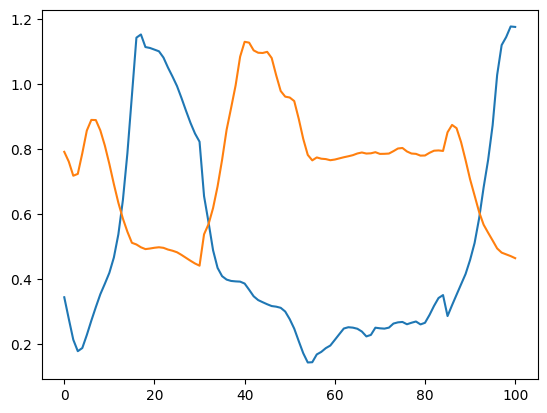

In [237]:
vis_scores_back = []
vis_scores_front = []
for q_1 in self.q_1s:
    vis_scores_back.append(get_vision_score(torch.as_tensor(q_1[-1]),vision_svm_back))
    vis_scores_front.append(get_vision_score(torch.as_tensor(q_1[-1]),vision_svm_front))
plt.plot(vis_scores_back)
plt.plot(vis_scores_front)

In [ ]:
planner.ros_handler.move_robots_to_configuration(planner.q_1s[0][0],None,10)
planner.ros_handler.move_robots_to_configuration(None,planner.q_2s[0][0],10)

In [ ]:
for i,(q_obj_cp) in enumerate(q_objs_all):
    b_spline = BSpline(q_obj_cp,3)
    q_obj = b_spline.fast_batch_evaluate(np.linspace(0,1,40))
    # meshcat.SetLineSegments('x1',T@vector_origin,T@vector_x,rgba=Rgba(1,0,0,1))
    meshcat.SetLineSegments('/obj_trajectory/'+str(i),q_obj[:-1,4:].T,q_obj[1:,4:].T,)

In [102]:
bspline_1_col = BSpline(
    planner.replan_data.result["robot_1_control_points"],
    opt_collision.order,
)
bspline_2_col = BSpline(
    planner.replan_data.result["robot_2_control_points"],
    opt_collision.order,
)
bspline_obj_col = BSpline(
    planner.replan_data.result["carried_object_control_points"],
    opt_collision.order,
)
print_collision_score_on_samples(20,planner,bspline_1_col,bspline_2_col)

0.0


IndexError: deque index out of range

In [39]:
meshcat.web_url()

'http://localhost:7003'

In [238]:

for i,(q_obj_cp) in enumerate(q_objs_all):
    b_spline = BSpline(q_obj_cp,3)
    q_obj = b_spline.fast_batch_evaluate(np.linspace(0,1,40))
    # meshcat.SetLineSegments('x1',T@vector_origin,T@vector_x,rgba=Rgba(1,0,0,1))
    meshcat.SetLineSegments('/obj_trajectory/'+str(i),q_obj[:-1,4:].T,q_obj[1:,4:].T,)
planner.obstacles = []
planner.stop_recording_simulation()

1
2
3
4
5
6
7
8


9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102


In [ ]:
len(planner.ros_handler.joints_1_history)

In [ ]:
%%timeit
np.array(planner.ros_handler.joints_1_history)
np.array(planner.ros_handler.joints_2_history)

In [ ]:
# from collections import deque
# # planner.ros_handler.joints_1_history
# max_store_seconds = 100
# max_size = max_store_seconds*planner.ros_handler.topic_frequency
# planner.ros_handler.joints_1_history = deque(maxlen=max_size)  
# planner.ros_handler.joints_2_history = deque(maxlen=max_size)  
# planner.ros_handler.joints_dot_1_history = deque(maxlen=max_size)  
# planner.ros_handler.joints_dot_2_history = deque(maxlen=max_size)  
# planner.ros_handler.joints_dot_1_filtered_history = deque(maxlen=max_size)  
# planner.ros_handler.joints_dot_2_filtered_history = deque(maxlen=max_size)  

In [ ]:
# planner.ros_handler.move_robots_to_configuration(planner.q_1s[0][0],planner.q_2s[0][0],10)



In [ ]:
plt.plot((Tss),'--')
got_tag
# point_cloud_viz.update()

In [ ]:
planner.q_1s

In [ ]:
s = np.vstack(actual_q1s)
plt.plot(np.linspace(planner.ts[0][0]-2.,planner.ts[-1][-1],s.shape[0])*0.95,s)
plt.plot(np.hstack(planner.ts),np.vstack(planner.q_1s), '--')

In [ ]:
robot_1_collision_checker = torch.compile(robots[0].collision_model.link_collision_modules["all_geometries"].to('cpu'),dynamic=True)
robot_2_collision_checker = torch.compile(robots[1].collision_model.link_collision_modules["all_geometries"].to('cpu'),dynamic=True)
# cc = 
num_eval_points = 20
q_1 = torch.as_tensor(np.column_stack((bspline_1.fast_batch_evaluate(np.linspace(0,1,num_eval_points)), np.zeros((num_eval_points,2)))))
q_2 = torch.as_tensor(np.column_stack((bspline_2.fast_batch_evaluate(np.linspace(0,1,num_eval_points)), np.zeros((num_eval_points,2)))))

obstacle_points = torch.randn(400,3)
obstacle_radii = torch.tensor(0.04, dtype=torch.float32, device='cpu').expand(400, 1)

robot_1_collision_checker(q_1,obstacle_points,obstacle_radii)
robot_2_collision_checker(q_2,obstacle_points,obstacle_radii)

In [ ]:
meshcat.SetProperty("/drake/contact_forces",'visible',False)
meshcat.SetProperty("/drake/proximity",'visible',False)

In [ ]:
print_collision_score_on_samples(10,planner,bspline_1_col,bspline_2_col)
# planner.ros_handler.topic_frequency = 30

In [ ]:
def follow_pointwise_trajectory(self,q_1s,q_2s,q_1_dots,q_2_dots,q_1_dotdots,q_2_dotdots, Ts, start_time):
    # if self.simulation:
    #     for q_1,q_1_dot,q_2,q_2_dot,t  in zip(q_1s,q_2_dots,q_1s,q_2_dots,np.linspace(0,time,num_steps)):
    #         self.viz_helper.set_position('robot_1',q_1)
    #         self.viz_helper.set_position('robot_2',q_2)
    #         self.viz_helper.diagram_context.SetTime(self.simulation_time + t)
    #         self.viz_helper.publish()
    #     self.simulation_time += time
    #     return 
    # http://wiki.ros.org/joint_trajectory_controller/UnderstandingTrajectoryReplacement
    goal_1 = FollowJointTrajectoryGoal()
    goal_1.trajectory.joint_names = self.JOINT_NAMES
    num_steps = len(q_1s)
    tol = ros.Duration.from_sec(0.01)
    t0 = 0.00
    Ts += t0
    print('start time',start_time)
    for q_1,q_1_dot,q_1_dotdot,t  in zip(q_1s[1:],q_1_dots[1:],q_1_dotdots[1:],np.linspace(t0,Ts,num_steps)[1:]):
        msg_point = JointTrajectoryPoint()
        msg_point.positions = q_1
        msg_point.velocities = q_1_dot
        msg_point.accelerations = q_1_dotdot
        msg_point.time_from_start = ros.Duration.from_sec(t)
        goal_1.trajectory.points.append(msg_point)
        goal_1.goal_time_tolerance = tol
        # print(t0,Ts,num_steps)
    goal_2 = FollowJointTrajectoryGoal()
    goal_2.trajectory.joint_names = self.JOINT_NAMES
    for q_2,q_2_dot,q_2_dotdot,t  in zip(q_2s[1:],q_2_dots[1:],q_2_dotdots[1:],np.linspace(t0,Ts,num_steps)[1:]):
        msg_point = JointTrajectoryPoint()
        msg_point.positions = q_2
        msg_point.velocities = q_2_dot
        msg_point.accelerations = q_2_dotdot
        msg_point.time_from_start = ros.Duration.from_sec(t)
        goal_2.trajectory.points.append(msg_point)
        goal_2.goal_time_tolerance = tol
    goal_1.trajectory.header.stamp = ros.Time.from_sec(start_time)
    goal_2.trajectory.header.stamp = ros.Time.from_sec(start_time)
    # print(goal_1.trajectory)
    self.client_1.send_goal(goal_1)
    self.client_2.send_goal(goal_2)
planner.ros_handler.follow_pointwise_trajectory = partial(follow_pointwise_trajectory,planner.ros_handler)

In [ ]:
import pickle
with open('ffff','wb') as f:
    pickle.dump((got_tag_at_t,self.obstacles,self.q_1s,self.q_2s,self.ts,actual_q1s,actual_q2s,Tss),f)
with open('ffff','rb') as handle:
    b = pickle.load(handle)
b

In [ ]:
plt.plot(Tss)
# planner.stop_recording_simulation()

In [ ]:
meshcat.web_url()

In [ ]:

s_ = np.linspace(0,1,15)
q_1s = self.implemented_trajectory['bspline_1'].fast_batch_evaluate(s_)
q_2s = self.implemented_trajectory['bspline_2'].fast_batch_evaluate(s_)
q_objs = self.implemented_trajectory['bspline_obj'].fast_batch_evaluate(s_)
# self.check_path_for_collision()

meshcat.StartRecording(frames_per_second=30.0)

for t,q_1,q_2,q_obj in zip(np.linspace(0,1,15),q_1s,q_2s,q_objs):
    
    q_1 = np.concatenate([q_1,np.zeros(2)])
    
    q_2 = np.concatenate([q_2,np.zeros(2)])
    # q_obj = bspline_obj_col.evaluate(s)
    
    # print(g_score_fake_function_repsum.call({'x':np.concatenate([q_obj,q_1,q_2,np.zeros(6)]),'fk_S':opt_data_collision.parameters[opt_info.svm_support_vectors],'A':opt_data_collision.parameters[opt_info.svm_weights]}))
    # print(g_translation)
    viz_helper.set_position('robot_0',q_1)
    viz_helper.set_position('robot_1',q_2)
    viz_helper.set_position('carried_object',q_obj)
    

    viz_helper.diagram_context.SetTime(t)
    # viz_helper.publish()
    viz_helper.publish_diagram()
meshcat.StopRecording()
# print('Success?',opt_collision.optimization_data['debug'].within_bounds())

# print(opt_collision.optimization_data['debug'].result["duration"])
meshcat.PublishRecording()

In [ ]:
planner.stop_recording_simulation()